In [1]:
import sys
import numpy as np
from pylab import gca
import numpy as np
import math
from tqdm import tqdm
import torch
import torchvision
import torch.nn as nn
from torch.utils import data
import torch.nn.functional as F
from torchvision import transforms
from torchvision.utils import save_image
from torchvision.datasets import MNIST
import torchvision.transforms.functional as TF
from torch.optim import lr_scheduler
import time
import os
from skimage.metrics import structural_similarity as ssim_id
from diffusionsr.analysis.plotting_functions import frame_tick, legend
import cv2
import os
from torchvision import transforms
from torch.utils.data import DataLoader
from pathlib import Path
from torch.utils.data import Dataset
import pdb
from PIL import Image
import matplotlib.pyplot as plt 
# print(os.listdir('.'))
from diffusionsr.datasets.dataset import SimulationXZDataset
import wandb

# from datasets.dataset import TemperatureXZDataset
from diffusionsr.runners.train_diffusion import forwardpass
from diffusionsr.analysis.analysis_functions import predict_lrenc, predict_mobilenet, predict_ddim_diffusion,predict_modified_diffusion, predict_diffusion, plot_images, get_profile, load_mobilenet, load_encoder, load_diffusion, PSNR, SSIM, multifield_plot_images
from diffusionsr.models.diffusion_model import Unet
from diffusionsr.models.lr_encoder_model import rrdbnet_encoder as rrdbnet_x4

### Define results directory and general parameters


In [2]:
wandb_id = 'p4c77tn2'
api  = wandb.Api()
run = api.run(f'fogoke/Flow3D_SuperResolution/{wandb_id}')
config = run.config


In [3]:
config

{'gpu': '4',
 'config': 'ss316l_updated_simulations_longer.yml',
 'epochs': 1000,
 'fields': 'temperature',
 'n_steps': '1',
 'encoding': True,
 'schedule': 'linear',
 'modeltype': 'diffusion',
 'timesteps': 1000,
 'batch_size': 32,
 'restart_dir': '/home/oogoke/DiffusionSR/runs/direct/diffusionimplicitencoded/2023_10_07_09_51_27_restart/standardize/n_steps_1',
 'root_folder': '/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data_expanded_frame',
 'conditioning': 'implicit',
 'learning_rate': '5e-5',
 'residual_flag': False,
 'use_pretrained': True,
 'downscale_method': 'direct',
 'normalize_method': 'standardize',
 'encoder_results_dir': '/home/oogoke/DiffusionSR/runs/direct/encoder/2023_10_06_17_48_51/standardize/n_steps_1'}

In [4]:
diffusion_results_dir = './runs/direct/diffusionimplicitencoded/2023_10_07_09_51_27/standardize/n_steps_1'#config['restart_dir']
encoder_results_dir = config['encoder_results_dir']
timesteps = config['timesteps']
conditioning = config['conditioning']
encoding = config['encoding']
schedule = config['schedule']
device= 'cuda:0'
encode_bool = encoding == 'True'

In [5]:


os.environ['CUDA_VISIBLE_DEVICES']  = "6, 7"
batch_size = 1
downscale_method = 'direct'
analysis_folder = f'analyzed_figures_paper_3_20/{timesteps}_{conditioning}_{schedule}_{downscale_method}'
os.makedirs( analysis_folder, exist_ok = True)

data_folder = config['root_folder']
train_dataset = SimulationXZDataset(downscale_method = 'direct', split = 'train', root_folder = data_folder , return_info = True, field_names = ['temperature'])
test_dataset = SimulationXZDataset(downscale_method ='direct', split = 'test', root_folder = data_folder, return_info = True, field_names = ['temperature'])
dev_dataset = SimulationXZDataset(downscale_method = 'direct', split = 'dev', root_folder = data_folder, return_info = True, field_names = ['temperature'])

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, drop_last=True)
dev_dataloader = DataLoader(dev_dataset, batch_size=1, shuffle=False, drop_last=True)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False, drop_last=True)


Using normalize method: ... standardize
Using specific fields,  ['temperature']
Processing dataset with 1 fields
Downscale factor:  2
Using normalize method: ... standardize
Using specific fields,  ['temperature']
Processing dataset with 1 fields
Downscale factor:  2
Using normalize method: ... standardize
Using specific fields,  ['temperature']
Processing dataset with 1 fields
Downscale factor:  2


In [6]:
train_dataset[0][0].shape

(1, 60, 60)

In [7]:
from diffusionsr.runners.train_diffusion import DiffusionModel

def initialize_diffusion(diff_dir, enc_dir, datasets, timesteps, conditioning, encoding, schedule, device):
    ''' 
    Parameters:
        diff_dir: (str) Diffusion results directory
        enc_dir: (str) Encoder results directory
        datasets: (tuple or list) The three dataset objects corresponding to the train/validation/test splits, in the order (train, validation, test).
        timesteps: (int) The number of timesteps used for the diffusion model during training
        conditioning: (boolean) If true, the diffusion model assumes the LR passes through an encoder before being used for conditioning
        schedule: (str) Variance schedule used for training the diffusion model
        device: (str) 'cuda' for GPU, 'cpu' for CPU.
    Returns:
        diffusion_model: Custom DiffusionModel object that enables sampling with either DDIM or DDPM samplers.
    '''

    diffusion_model = DiffusionModel(results_folder=diff_dir,
                                    lr_encoder_folder=enc_dir,
                                    train_dataset=datasets[0],
                                    dev_dataset=datasets[1],
                                    test_dataset=datasets[2],
                                    timesteps=timesteps,
                                    conditioning=conditioning,
                                    encoding=encoding,
                                    schedule=schedule,
                                    device=device,enc_output = False
                                    )
    diffusion_model.load_saved_model()
    return diffusion_model

diff_model = initialize_diffusion(diff_dir=diffusion_results_dir,
                                  enc_dir=encoder_results_dir,
                                  datasets=[train_dataset,
                                            dev_dataset, test_dataset],
                                  timesteps=timesteps,
                                  conditioning=conditioning,
                                  encoding=encoding,
                                  schedule=schedule,
                                  device=device)

new_diffusion_model = initialize_diffusion(diff_dir  = config['restart_dir'],
                                            enc_dir=encoder_results_dir,
                                            datasets=[train_dataset,
                                            dev_dataset, test_dataset],
                                            timesteps=timesteps,
                                            conditioning=conditioning,
                                            encoding=encoding,
                                            schedule=schedule,
                                            device='cuda:1')
lr_enc = load_encoder(encoder_results_dir, dataset = train_dataset)


Loading encoder ... encoding = True
TIMESTEPS == 1000, Schedule = linear
Loading model from /home/oogoke/DiffusionSR/runs/direct/diffusionimplicitencoded/2023_10_07_09_51_27/standardize/n_steps_1
model found, loading
Loading encoder ... encoding = True
TIMESTEPS == 1000, Schedule = linear
Loading model from /home/oogoke/DiffusionSR/runs/direct/diffusionimplicitencoded/2023_10_07_09_51_27_restart/standardize/n_steps_1
model found, loading


In [9]:
def compute_alpha(beta, t):
    beta = torch.cat([torch.zeros(1).to(beta.device), beta], dim=0).to(device)
    # print(beta.device, t.device)
    a = (1 - beta).cumprod(dim=0).index_select(0, t + 1).view(-1, 1, 1, 1)
    return a

def predict_modified_all_ddim_diffusion(model, lr_enc, res, hr, lr, upscaled_lr, encoding, dataset, seq, timesteps = 200, skip = 1, schedule = 'linear', **kwargs):
    
    # skip =timesteps // self.args.timesteps
    seq = range(0, timesteps, skip)
    
    def cosine_beta_schedule(timesteps, s=0.008):

        steps = timesteps + 1
        x = torch.linspace(0, timesteps, steps)
        alphas_cumprod = torch.cos(
            ((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        return torch.clip(betas, 0.0001, 0.9999)

    def linear_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start, beta_end, timesteps)


    def quadratic_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        return torch.linspace(beta_start**0.5, beta_end**0.5, timesteps) ** 2

    def sigmoid_beta_schedule(timesteps):
        beta_start = 0.0001
        beta_end = 0.02
        betas = torch.linspace(-6, 6, timesteps)
        return torch.sigmoid(betas) * (beta_end - beta_start) + beta_start
    if schedule == 'linear':
        betas = linear_beta_schedule(timesteps=timesteps)
    elif schedule == 'quadratic':
        betas = quadratic_beta_schedule(timesteps=timesteps)
    elif schedule == 'cosine':
        betas = cosine_beta_schedule(timesteps=timesteps)
    elif schedule == 'sigmoid':
        betas = sigmoid_beta_schedule(timesteps=timesteps)
    b = betas
    device = next(model.parameters()).device
    if len(lr.shape) < 4:
        img = (lr.view(lr.shape[0], 1, lr.shape[1], lr.shape[2]).to(device))
        target = (hr.view(hr.shape[0], 1, hr.shape[1], hr.shape[2]).to(device))
    else:
        img = lr.to(device)
        target = hr.to(device)
    if encoding:
            # x_e = forwardpass(lr_enc, lr.to(device).float(), factor = train_dataset.factor)
        if len(lr.shape)< 4:
            x_e = forwardpass(lr_enc, lr.view(lr.shape[0],1, lr.shape[1], lr.shape[2]).to(device).float(), factor = 2)
        else:
            x_e = forwardpass(lr_enc, lr.to(device).float(), factor = 2)
    else:
        x_e = upscaled_lr.to(device).float().repeat(1,1,1, 1)
    
    # batches = num_to_groups(1, lr.shape[0])
    shape=hr.shape
    # print(timesteps, batches, img.shape[0])
    # print(x_e.shape)
    # with torch.no_grad():
    #     n = img.size(0)
    #     seq_next = [-1] + list(seq[:-1])
    #     x0_preds = []
        
    #     x = torch.randn(shape, device=device)
    #     xs = [x]
    #     for i, j in zip(reversed(seq), reversed(seq_next)):
    #         t = (torch.ones(n) * i).to(x.device)
    #         next_t = (torch.ones(n) * j).to(x.device)
    #         at = compute_alpha(b, t.long())
    #         at_next = compute_alpha(b, next_t.long())
    #         xt = xs[-1].to('cuda')
    #         et = model(x, t, x_e)#model(xt, t)
    #         x0_t = (xt - et * (1 - at).sqrt()) / at.sqrt()
    #         x0_preds.append(x0_t.to('cpu'))
    #         c1 = (
    #             kwargs.get("eta", 0) * ((1 - at / at_next) * (1 - at_next) / (1 - at)).sqrt()
    #         )
    #         c2 = ((1 - at_next) - c1 ** 2).sqrt()
    #         xt_next = at_next.sqrt() * x0_t + c1 * torch.randn_like(x) + c2 * et
    #         xs.append(xt_next.to('cpu'))
    with torch.no_grad():
        x = torch.randn(shape, device=device)
        n = x.size(0)
        seq_next = [-1] + list(seq[:-1])
        x0_preds = []
        xs = [x]
        for i, j in zip(reversed(seq), reversed(seq_next)):
            t = (torch.ones(n) * i).to(x.device)
            next_t = (torch.ones(n) * j).to(x.device)
            at = compute_alpha(b, t.long())
            at_next = compute_alpha(b, next_t.long())
            xt = xs[-1].to(device)
            et = model(xt, t, x_e)
            x0_t = (xt - et * (1 - at).sqrt()) / at.sqrt()
            x0_preds.append(x0_t.to('cpu'))
            c1 = (
                kwargs.get("eta", 0) * ((1 - at / at_next) * (1 - at_next) / (1 - at)).sqrt()
            )
            c2 = ((1 - at_next) - c1 ** 2).sqrt()
            xt_next = at_next.sqrt() * x0_t + c1 * torch.randn_like(x) + c2 * et
            xs.append(xt_next.to('cpu'))
    # print(len(x0_preds),x0_preds[0].shape, len(xs))
    # return xs, x0_preds
    result = dataset.unscale_data(xs[-1], input_type = 'hr') 
    plt.imshow(result[0][0].cpu().detach().numpy().T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000)
    plt.show()
    return dataset.unscale_data(lr, input_type='lr'), result, dataset.unscale_data(target.cpu(), input_type = 'hr'), xs, b


In [10]:
def cosine_beta_schedule(timesteps, s=0.008):

        steps = timesteps + 1
        x = torch.linspace(0, timesteps, steps)
        alphas_cumprod = torch.cos(
            ((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        return torch.clip(betas, 0.0001, 0.9999)

def linear_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start, beta_end, timesteps)


def quadratic_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start**0.5, beta_end**0.5, timesteps) ** 2

def sigmoid_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    betas = torch.linspace(-6, 6, timesteps)
    return torch.sigmoid(betas) * (beta_end - beta_start) + beta_start
def get_timesteps(schedule = 'linear'):
    if schedule == 'linear':
        betas = linear_beta_schedule(timesteps=timesteps)
    elif schedule == 'quadratic':
        betas = quadratic_beta_schedule(timesteps=timesteps)
    elif schedule == 'cosine':
        betas = cosine_beta_schedule(timesteps=timesteps)
    elif schedule == 'sigmoid':
        betas = sigmoid_beta_schedule(timesteps=timesteps)
    return betas 

In [45]:



def compute_alpha(beta, t, device = 'cuda'):
    beta = torch.cat([torch.zeros(1).to(beta.device), beta], dim=0).to(device)
    # print(beta.device, t.device)
    a = (1 - beta).cumprod(dim=0).index_select(0, t + 1).view(-1, 1, 1, 1)
    return a



def predict_streamlined_ddim_diffusion(model,  hr, lr, x_e, dataset, timesteps = 200, skip = 1, schedule = 'linear', **kwargs):
    
    # skip =timesteps // self.args.timesteps
    seq = range(0, timesteps, skip)
    print(timesteps)
    b = get_timesteps(schedule)
    
    device = next(model.parameters()).device
    # print(device)
    if len(lr.shape) < 4:
        target = (hr.view(hr.shape[0], 1, hr.shape[1], hr.shape[2]).to(device))
    else:
        target = hr.to(device)
        
    shape=hr.shape
    with torch.no_grad():
        x = torch.randn(shape, device=device)
        n = x.size(0)
        seq_next = [-1] + list(seq[:-1])
        x0_preds = []
        xs = [x]
        for i, j in zip(reversed(seq), reversed(seq_next)):
            t = (torch.ones(n) * i).to(x.device)
            next_t = (torch.ones(n) * j).to(x.device)
            # print(x.device, b.device, t.device)
            at = compute_alpha(b, t.long(), device = x.device)
            at_next = compute_alpha(b, next_t.long(), device = x.device)
            xt = xs[-1].to(device)
            model.to(device)
            et = model(xt, t, x_e)
            x0_t = (xt - et * (1 - at).sqrt()) / at.sqrt()
            x0_preds.append(x0_t.to('cpu'))
            c1 = (
                kwargs.get("eta", 0) * ((1 - at / at_next) * (1 - at_next) / (1 - at)).sqrt()
            )
            c2 = ((1 - at_next) - c1 ** 2).sqrt()
            xt_next = at_next.sqrt() * x0_t + c1 * torch.randn_like(x) + c2 * et
            xs.append(xt_next.to('cpu'))

    result = dataset.unscale_data(xs[-1], input_type = 'hr') 
    return dataset.unscale_data(lr, input_type='lr'), result, dataset.unscale_data(target.cpu(), input_type = 'hr'), xs, b





In [46]:
def predict_refactored_diffusion(diff_model, lr_enc, res, hr, lr, upscaled_lr, dataset, skip = 50):

    '''
    Return the predictions for the Diffusion model given an input batch
    Parameters:
    diff_model: DiffusionModel object
    lr_enc: Torch network module object, representing the trained RRDN encoder model
    res: Torch tensor, Residual between HR and LR data
    hr: Torch tensor, High Resolution data
    lr: Torch tensor, Low Resolution data
    upscaled_lr: Torch tensor, Bicubic upscaled low resolution data
    dataset: Dataset object, used for rescaling data
    Returns:
    Low resolution data, scaled to original space, 4-D numpy array (batch, channels, height, width)
    Output (Super-resolution), scaled to original space, 4-D numpy array
    High resolution data, scaled to original space, 4-D numpy array 
    '''
    device = diff_model.device
    if len(lr.shape) < 4:
        img = (lr.view(lr.shape[0], 1, lr.shape[1], lr.shape[2]).to(device))
        target = (hr.view(hr.shape[0], 1, hr.shape[1], hr.shape[2]).to(device))
    else:
        img = lr.to(device)
        target = hr.to(device)
    if len(lr.shape) < 4:
        input_lr = lr.view(lr.shape[0],1, lr.shape[1], lr.shape[2]).to(device).float()
    else:
        input_lr = lr.to(device).float()
    
    x_e = forwardpass(diff_model.lr_enc, input_lr, factor = diff_model.train_dataset.factor, output = diff_model.enc_output,transform_rescale=diff_model.transform_rescale, dataset = dataset)

    all_images = diff_model.batch_sample(dataset = dataset, batch = hr.to(device), x_e = x_e.to(device), sampler = 'DDIM', skip= skip) 

    result = dataset.unscale_data(all_images.cpu().numpy()[-1], input_type = 'hr') #+ dataset.unscale_data(upscaled_lr.numpy(), input_type = 'upscaled_lr')
    print(result.shape)
    
    return dataset.unscale_data(lr, input_type='lr'), result, dataset.unscale_data(target.cpu(), input_type = 'hr')


 12%|█▏        | 526/4423 [00:01<00:14, 269.58it/s]


(1, 1, 60, 60)
DIVISION FACTOR 2
30
DIVISION FACTOR 1
60
DIVISION FACTOR 1
60
DIVISION FACTOR 1
60
DIVISION FACTOR 1
60


 52%|█████▏    | 2304/4423 [00:05<00:05, 409.41it/s]


KeyboardInterrupt: 

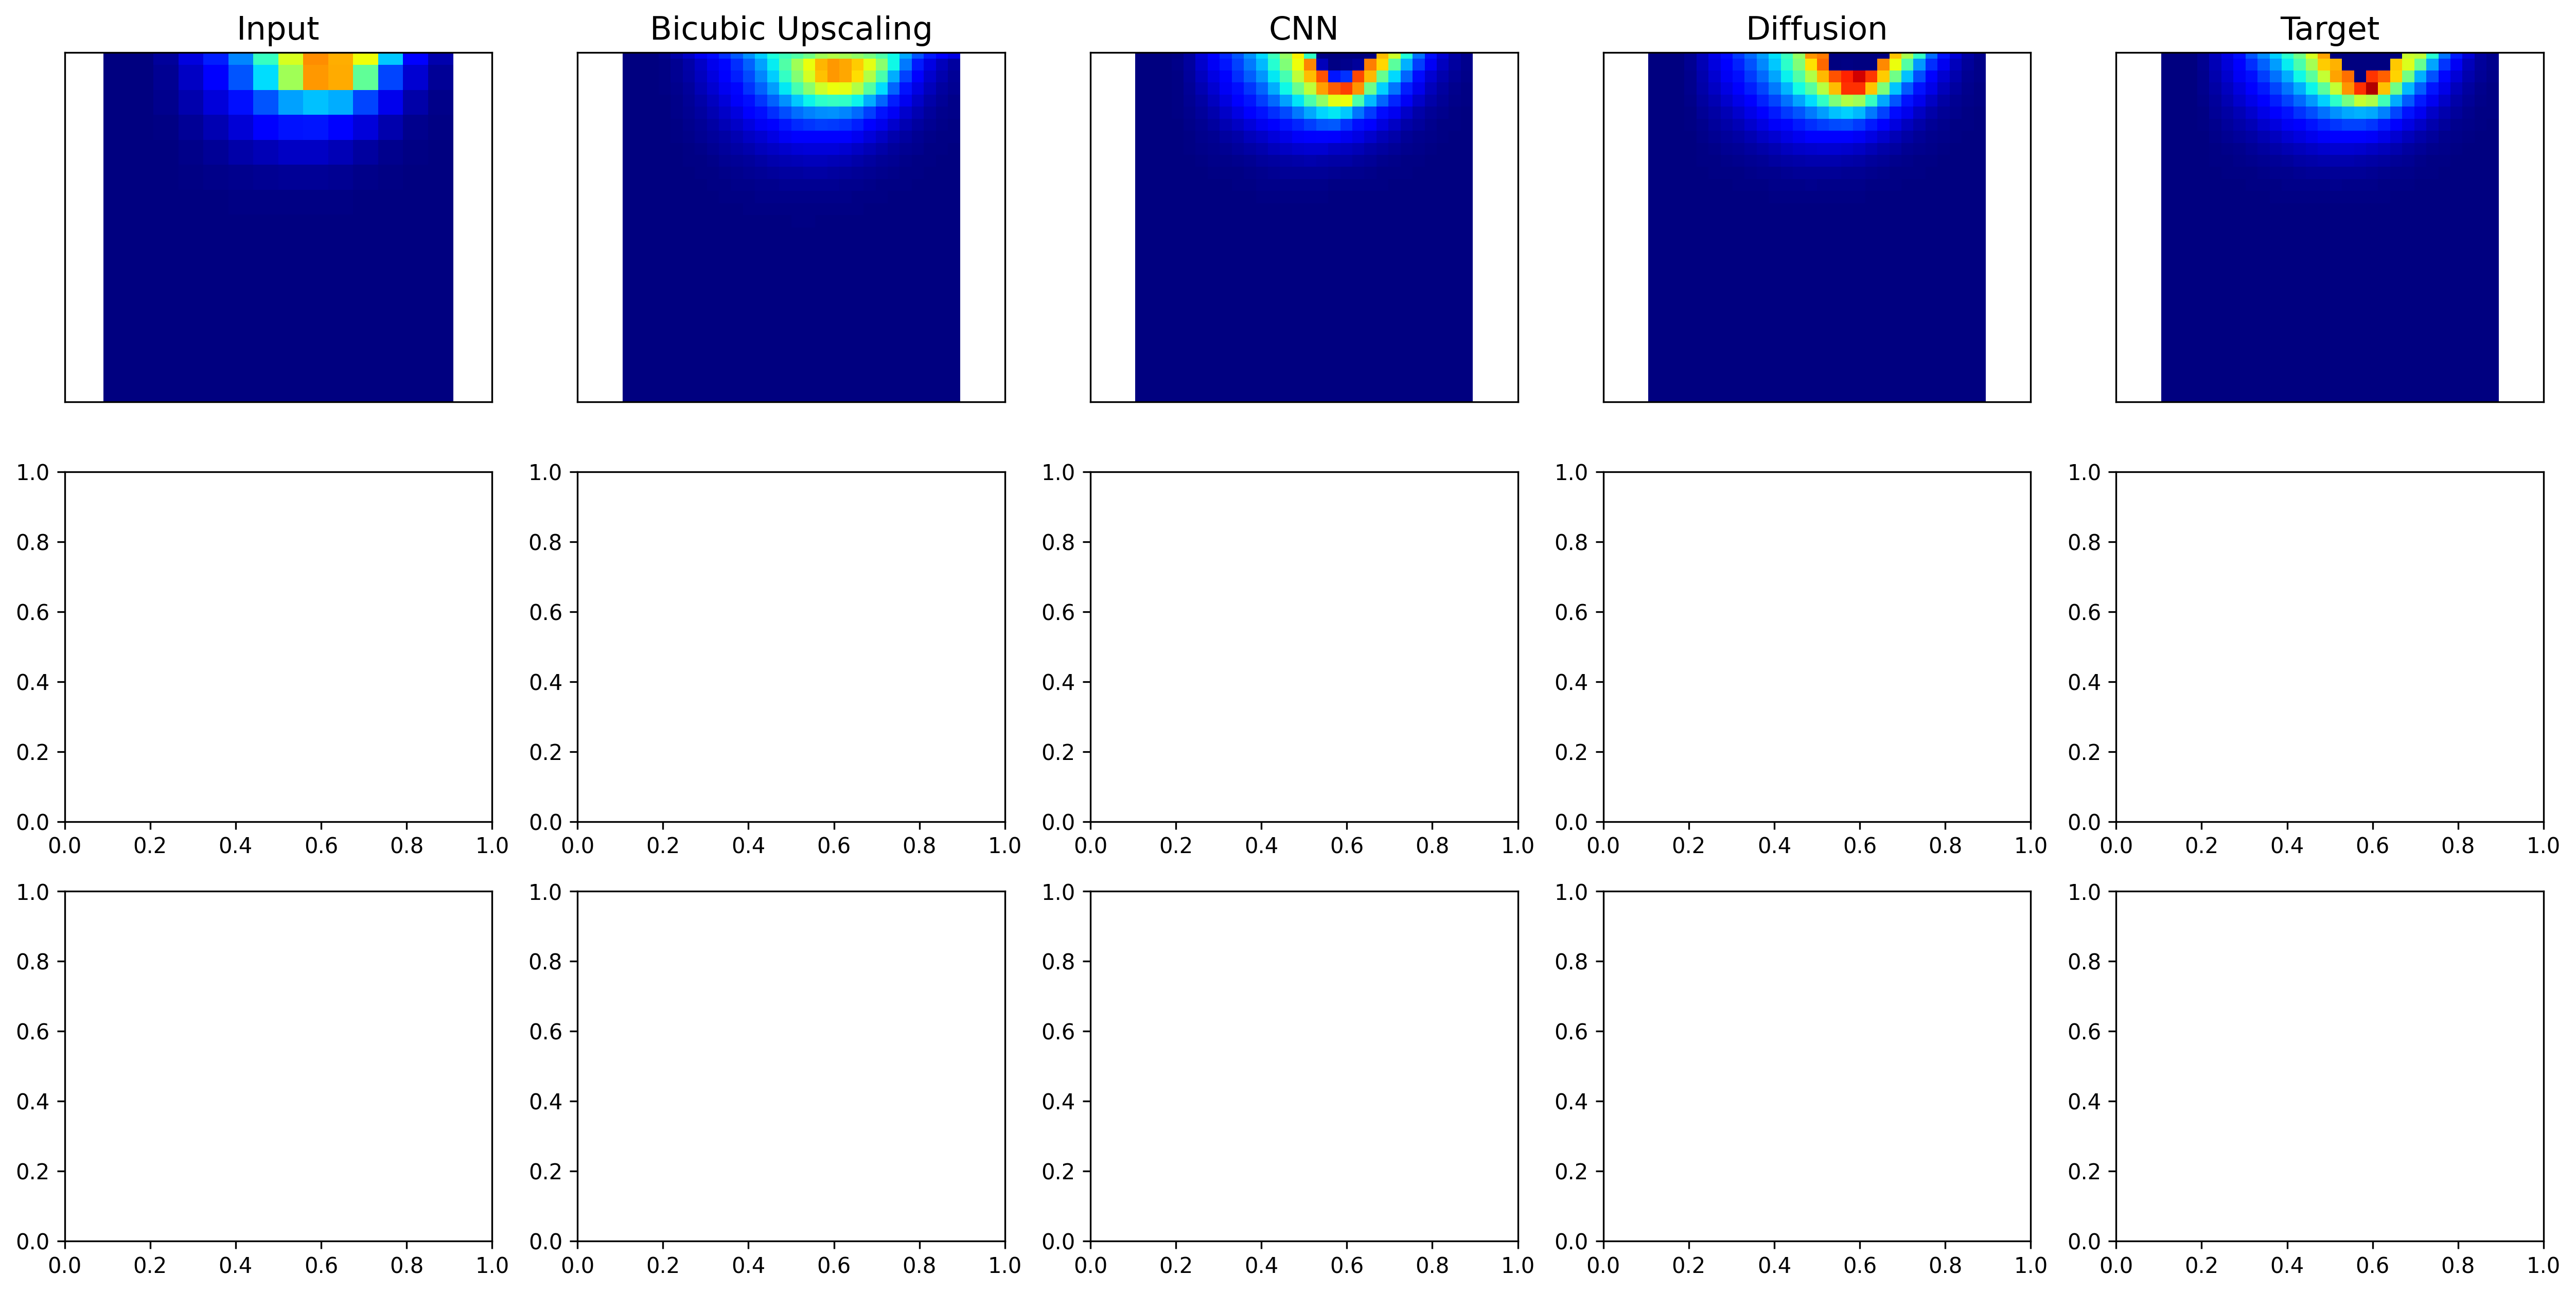

In [11]:
# for array in [input, upscaled_lr_data, result_diffusion, target]:

scaling_factor = 1

labels = ['Input', 'Bicubic Upscaling', 'CNN', 'Diffusion', 'Target']
batch_idxs = [399,2617,1708] # 260v900 364v900 400v650
# batch_idxs = [0,1,2]
timesteps = 1000
skip = 50

# for m in range(-60, -50):
batch_idxs = [500+(95 - 15) -55 ,2617+(95-37)-55,4400 + 21 -55 - 98*1] 
for k in range(10):
    fig, axs = plt.subplots(nrows=3, ncols=5, figsize=(2.8*7.4*scaling_factor, 10*scaling_factor), dpi=300)
    fig.patch.set_alpha(0)
    for j,(row, batch_index) in enumerate(zip(axs, batch_idxs)):
        for batch_idx, (res, hr, lr, upscaled_lr, info_full) in tqdm(enumerate(test_dataloader), total = len(test_dataloader) ):
            if batch_idx == batch_index:
                input, result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, train_dataset)
                input, result_diffusion, target = predict_refactored_diffusion(diff_model, lr_enc, res, hr, lr, upscaled_lr, test_dataloader.dataset, skip = skip)
                # input, result_diffusion, target, _, _ = predict_modified_ddim_diffusion(diff_model.model, lr_enc, res, hr, lr, upscaled_lr,encoding = encode_bool,dataset =  train_dataset,seq= None, timesteps = timesteps,skip = skip, schedule = 'linear')
                upscaled_lr_data = test_dataloader.dataset.unscale_data(upscaled_lr, input_type = 'upscaled_lr')
                for i, (ax, array, label) in enumerate(zip(row,[input, upscaled_lr_data, result, result_diffusion, target], labels )):
                    if i == 0:
                        division_factor = 2
                        bound = 10
                    else:
                        division_factor  = 1
                        bound = 20
                    print("DIVISION FACTOR", division_factor)
                    xx, yy = np.meshgrid(np.arange(28//division_factor)*10*division_factor, np.arange(30//division_factor)*10*division_factor)
                    print(array.shape[-1])
                    im = ax.pcolormesh(xx, yy, array[0][0][12//division_factor:40//division_factor, (bound//2):-bound].T,vmin = 293, vmax = 5000,cmap='jet')
                    ax.axis('equal')
                    ax.set_ylim([yy.min(), yy.max()])
                    # if i ==  0 and j == 0:
                        
                        
                        # frame_tick()
                    # else:
                    # ax.axis('off')
                    ax.set_title(label, fontsize = 15)
                    ax.xaxis.set_tick_params(labelbottom=False)
                    ax.yaxis.set_tick_params(labelleft =False)
                    # ax.invert_yaxis()
                    ax.set_xticks([])
                    ax.set_yticks([])
                    if j == len(axs) - 1  and i == 0:
                        ax.set_ylabel(r'z $[\mu m]$')
                        ax.set_xlabel(r'x $[\mu m]$')
            elif batch_idx > batch_index:
                break
            
    fig.subplots_adjust(wspace = 0.01)#, hspace = 0.1)
    # fig.subplots_adjust()


    # Add colorbar
    cax = fig.add_axes([0.91, 0.12, 0.02, 0.77])
    clb = fig.colorbar(im, cax=cax)

    clb.set_ticks([293, 1000, 2000, 3000, 4000, 5000])
    clb.ax.set_title(r'T$[K]$', fontsize=15)
    plt.show()

In [183]:
bulk_dataloader = DataLoader(test_dataset, batch_size=100, shuffle=True, drop_last=True)
inputs = []
results_cnn = []
results_diffusion = []
new_results_diffusion = []
results_ddim = []
targets = []
skip = 50
result_ddim_skips = {}
new_result_ddim_skips = {}
for batch_idx, (res, hr, lr, upscaled_lr, info_full) in tqdm(enumerate(bulk_dataloader), total = len(bulk_dataloader) ):
    print(res.shape)
#     if batch_idx == batch_index:
    input, result, target = predict_lrenc(lr_enc,res, hr, lr, upscaled_lr, train_dataset)
    x_e = forwardpass(diff_model.lr_enc, 
                      lr.to(device).float(), 
                      factor = diff_model.train_dataset.factor, 
                      output = diff_model.enc_output,
                      transform_rescale=diff_model.transform_rescale, 
                      dataset = diff_model.train_dataset)

    sample_output = train_dataset.unscale_data(diff_model.sample(diff_model.model, timesteps=timesteps, x_e=x_e.repeat(batch_size,1,1 ,1 ),
                        image_size=diff_model.train_dataset.img_shape,  batch_size=batch_size, channels=diff_model.channels)[-1], input_type = 'hr')
    print("Now sampling from new model")
    new_sample_output = train_dataset.unscale_data(new_diffusion_model.sample(new_diffusion_model.model, timesteps=timesteps, x_e=x_e.repeat(batch_size,1,1 ,1 ).to(new_diffusion_model.device),
                        image_size=diff_model.train_dataset.img_shape,  batch_size=batch_size, channels=diff_model.channels)[-1], input_type = 'hr')
    for skip_trial in [1, 10, 50, 100, 200, 500, 1000][::-1]:
        if skip_trial not in result_ddim_skips:
            result_ddim_skips[skip_trial] = []
            new_result_ddim_skips[skip_trial] = []
        print(f"Now using skip {skip_trial}")
        input, result_ddim, target, _, _ = predict_streamlined_ddim_diffusion(diff_model.model,
                                                                            hr = hr, 
                                                                                lr = lr,
                                                                                x_e = x_e,
                                                                                dataset = test_dataset,
                                                                                timesteps = timesteps,
                                                                                skip = skip_trial,
                                                                                schedule = 'linear')
        
        result_ddim_skips[skip_trial].append(result_ddim)
       
        input, new_result_ddim, target, _, _ = predict_streamlined_ddim_diffusion(new_diffusion_model.model,
                                                                            hr = hr, 
                                                                                lr = lr,
                                                                                x_e = x_e.to(new_diffusion_model.device),
                                                                                dataset = test_dataset,
                                                                                timesteps = timesteps,
                                                                                skip = skip_trial,
                                                                                schedule = 'linear')
        new_result_ddim_skips[skip_trial].append(new_result_ddim)

    targets.append(target)
    inputs.append(input)
    results_cnn.append(result)
    results_diffusion.append(sample_output)
    new_results_diffusion.append(new_sample_output)
    results_ddim.append(result_ddim)
    # break


  0%|          | 0/44 [00:00<?, ?it/s]

torch.Size([100, 1, 60, 60])


sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

Now sampling from new model


sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

...

  7%|▋         | 3/44 [34:46<7:55:15, 695.50s/it]

torch.Size([100, 1, 60, 60])


sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

  7%|▋         | 3/44 [35:12<8:01:06, 704.06s/it]


KeyboardInterrupt: 

In [157]:
targets

[tensor([[[[293.0000, 293.0000, 293.0000,  ..., 293.0000, 293.0000, 293.0000],
           [293.0000, 293.0000, 293.0000,  ..., 293.0000, 293.0000, 293.0000],
           [293.0000, 293.0000, 293.0000,  ..., 293.0000, 293.0000, 293.0000],
           ...,
           [299.1500, 299.1500, 299.1500,  ..., 299.1500, 299.1500, 299.1500],
           [299.1500, 299.1500, 299.1500,  ..., 299.1500, 299.1500, 299.1500],
           [299.1500, 299.1500, 299.1500,  ..., 299.1500, 299.1500, 299.1500]]],
 
 
         [[[293.0000, 293.0000, 293.0000,  ..., 293.0000, 293.0000, 293.0000],
           [293.0000, 293.0000, 293.0000,  ..., 293.0000, 293.0000, 293.0000],
           [293.0000, 293.0000, 293.0000,  ..., 293.0000, 293.0000, 293.0000],
           ...,
           [299.1500, 299.1500, 299.1500,  ..., 299.1500, 299.1500, 299.1500],
           [299.1500, 299.1500, 299.1500,  ..., 299.1500, 299.1500, 299.1500],
           [299.1500, 299.1500, 299.1500,  ..., 299.1500, 299.1500, 299.1500]]],
 
 
        

### Plot qualitative effect of diffusion timesteps

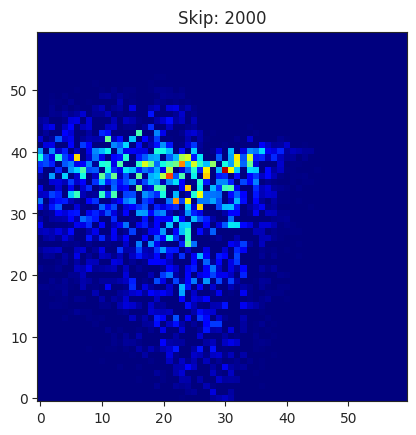

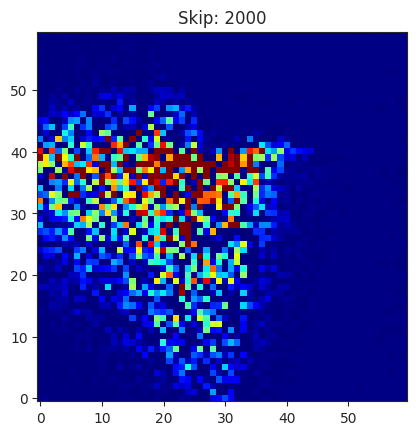

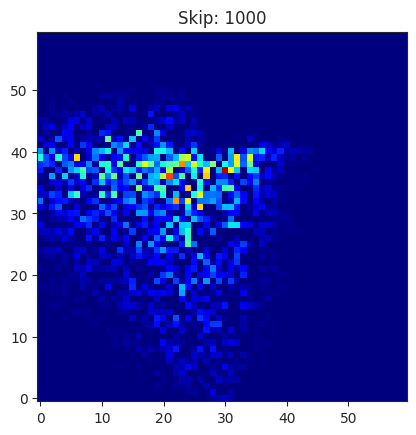

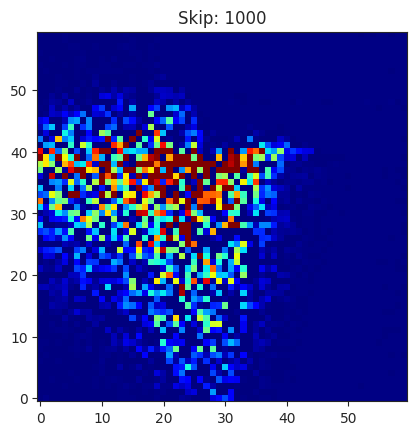

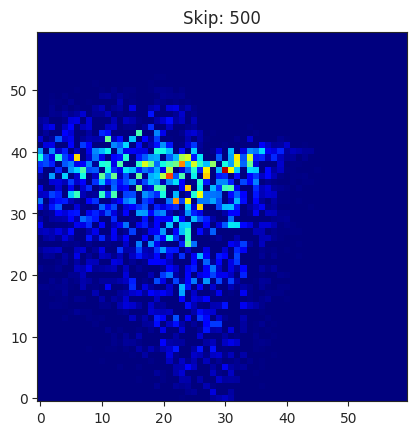

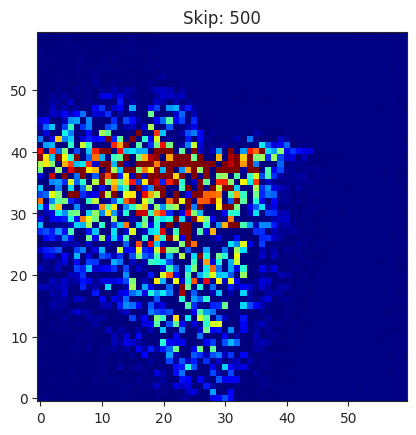

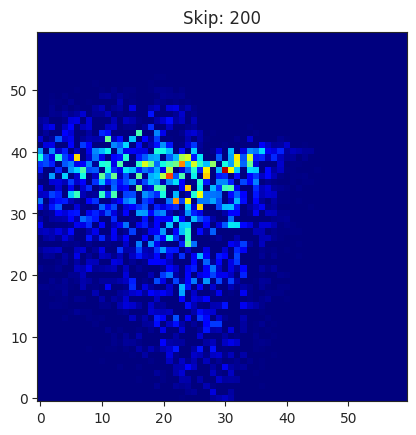

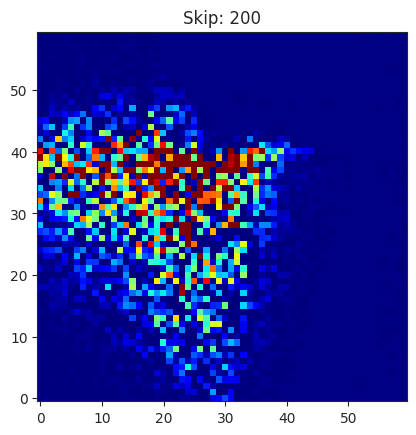

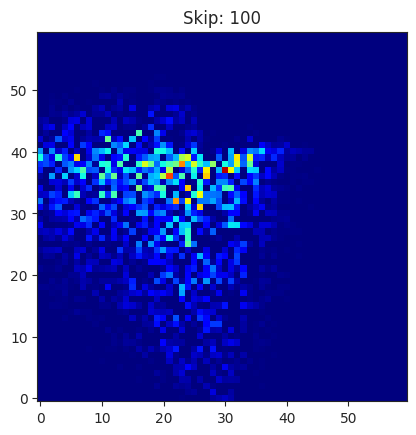

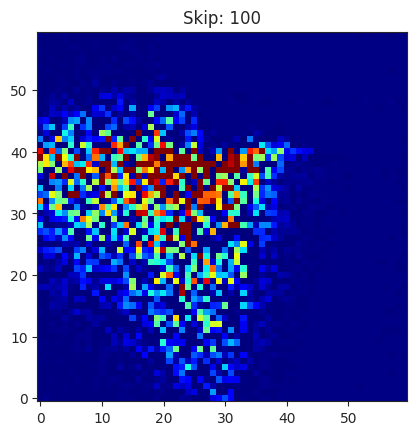

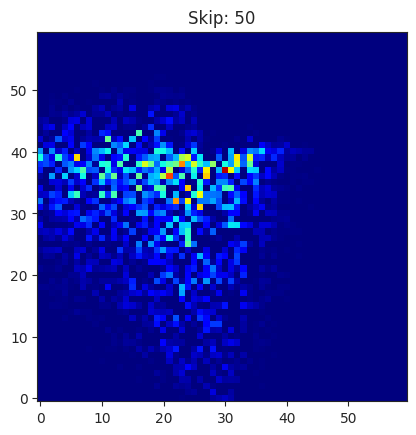

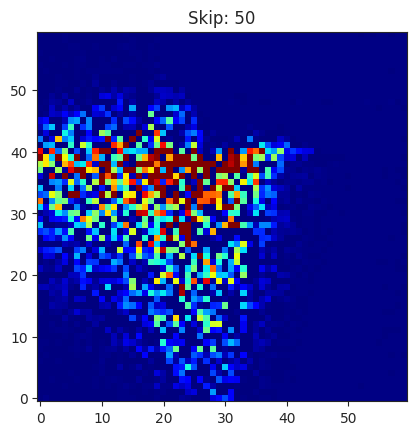

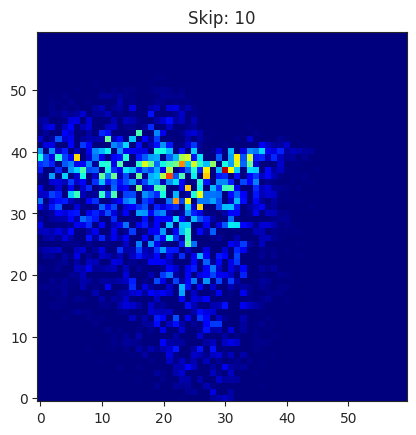

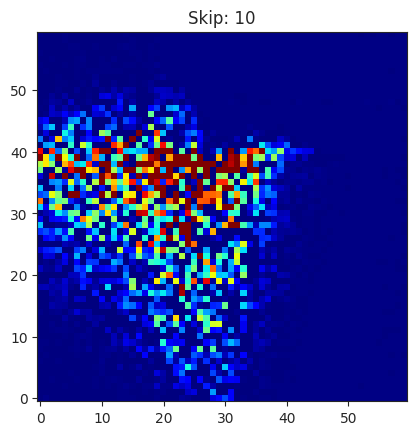

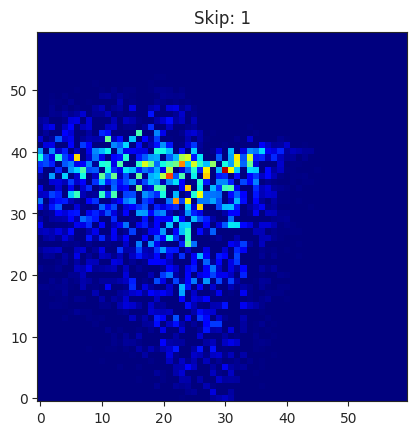

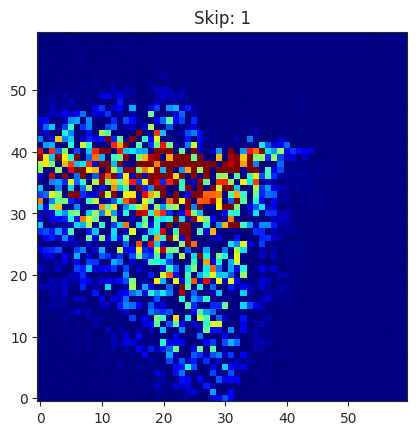

In [112]:
# plt.imshow(result_ddim_skips[100][0][0].T, cmap = 'jet', origin = 'lower', vmin = 293, vmax = 5000)
for skip in [1, 10, 50, 100, 200, 500, 1000, 2000][::-1]:
    # input, result_ddim, target, _, _ = predict_streamlined_ddim_diffusion(diff_model.model,
    #                                                                     hr = hr, 
    #                                                                         lr = lr,
    #                                                                         x_e = x_e,
    #                                                                         dataset = test_dataset,
    #                                                                         timesteps = timesteps,
    #                                                                         skip = skip,
    #                                                                         schedule = 'linear')
    plt.imshow(result_ddim[-1][0].T, cmap = 'jet', origin = 'lower', vmin = 293, vmax = 5000)
    plt.title(f"Skip: {skip}")
    plt.show()
    plt.imshow(result_ddim[-1][0].T, cmap = 'jet', origin = 'lower', vmin = 293, vmax = 1700)
    plt.title(f"Skip: {skip}")
    plt.show()

In [184]:
# %matplotlib 
from scipy.ndimage.morphology import distance_transform_bf

import skimage
import numpy as np 
# import matplotlib
# matplotlib.use('agg') 
from matplotlib import pyplot as plt 
import os
from skimage import measure
def find_keyhole_boundary(temp_2d, threshold = 1900, plate_height = 80):
    '''
    Temp_2d: Two dimensional temperature numpy array
    Threshold: Should be between melting point and filled keyhole value to find melt boundary, or melting point temperature to find keyhole boundary
    Plate height: Index corresponding to top surface of domain
    '''
    padded_T = np.pad(temp_2d, ((0,0),(10,10))) # pad to add empty space over the domain
    # plt.imshow(padded_T.T, origin = 'lower')
    # plt.show()
    contours = measure.find_contours(padded_T>threshold, 0.5) 
    idx = np.argmax([len(contour) for contour in contours])
    left = np.argmin(contours[idx][:,0]) # isolate the top path corresponding to keyhole boundary
    top = np.where((contours[idx][left:,1])> (plate_height+10 - 3))[0][0]  # refine the top path corresponding to keyhole boundary
    contour = contours[idx] - np.array([0,10]) # entire boundary, remove 10 to get rid of padding
    filtered_contour  = contours[idx][left + top:, :] - np.array([0,10]) # keyhole boundary, remove 10 to get rid of padding
    pores = [contours[c] - np.array([0,10]) for c in  range(len(contours)) if c != idx] # pores disconnected from keyhole boundary 
    return contour[:left + top, :], filtered_contour, pores
def fill_keyhole(temp, borderline = 293, plate_height = 30):
    '''
    Temp: Three dimensional temperature array
    '''
    temp = np.array(temp,dtype = float)[:, :plate_height]

    labeled_image = skimage.measure.label(temp>borderline, background = 1)
    # plt.imshow(labeled_image)
    # plt.title('label')
    # plt.show()
    props = skimage.measure.regionprops(labeled_image)
    volume = [prop.area for prop in props]
    
    idx_background = np.argmax(volume)
    for index, prop in enumerate(props):

        bbox = prop.bbox
        if bbox[-1] < temp.shape[-1]:
            continue
        if index == idx_background:
            continue
        else:
            temp[labeled_image == prop.label] = 10000
    # plt.figure(dpi = 300, figsize = np.array([4,3])*1.15)
    
    # plt.imshow(temp.T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000)
    # plt.title("Melt Pool, Keyhole Filled")
    # plt.axis('off')
    # plt.show()
    # # plt.imshow(temp.T, origin  = 'lower')
    # # plt.show()
    return temp
def extract_keyhole_temperatures(sample, plate_height, plot= False):

    if plot:
        plt.figure(dpi = 300, figsize = np.array([4,3])*1.15)
        
        plt.imshow(sample[:, :plate_height].T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000)
        plt.title("Melt Pool")
        plt.axis('off')
        plt.show()
    temp_2d = fill_keyhole(sample, borderline = 1000, plate_height = plate_height)
    if plot:
        plt.imshow(temp_2d.T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000)
        plt.title('filled')
        plt.show()
    criterion = np.logical_and(distance_transform_bf(temp_2d<5000)<1.1 , distance_transform_bf(temp_2d<5000)>0)
    filtered_temperatures = criterion*temp_2d
    temperature_values = filtered_temperatures[filtered_temperatures>0]
    if plot:
        plt.figure(dpi = 300, figsize = np.array([4,3])*1.15)
        plt.axis('off')
        plt.title('Keyhole Boundary Temperature Values')
        plt.imshow((criterion*temp_2d).T, origin = 'lower', vmin = 293, vmax = 5000, cmap ='jet')
        plt.show()
    return temperature_values

In [185]:
def concat_samples(samples):
    return torch.stack(samples).reshape(-1, samples[0].shape[1], samples[0].shape[2], samples[0].shape[3])

In [186]:
# temperature_values_gt = [extract_keyhole_temperatures(t[0], 41, plot = False) for t in concat_samples(targets)]
targets

[tensor([[[[293.0000, 293.0000, 293.0000,  ..., 293.0000, 293.0000, 293.0000],
           [293.0000, 293.0000, 293.0000,  ..., 293.0000, 293.0000, 293.0000],
           [293.0000, 293.0000, 293.0000,  ..., 293.0000, 293.0000, 293.0000],
           ...,
           [299.1500, 299.1500, 299.1500,  ..., 299.1500, 299.1500, 299.1500],
           [299.1500, 299.1500, 299.1500,  ..., 299.1500, 299.1500, 299.1500],
           [299.1500, 299.1500, 299.1500,  ..., 299.1500, 299.1500, 299.1500]]],
 
 
         [[[293.0000, 293.0000, 293.0000,  ..., 293.0000, 293.0000, 293.0000],
           [293.0000, 293.0000, 293.0000,  ..., 293.0000, 293.0000, 293.0000],
           [293.0000, 293.0000, 293.0000,  ..., 293.0000, 293.0000, 293.0000],
           ...,
           [299.1500, 299.1500, 299.1500,  ..., 299.1500, 299.1500, 299.1500],
           [299.1500, 299.1500, 299.1500,  ..., 299.1500, 299.1500, 299.1500],
           [299.1500, 299.1500, 299.1500,  ..., 299.1500, 299.1500, 299.1500]]],
 
 
        

[4003.0615, 4129.7231, 4167.1719, 4088.6904, 2277.593, 2281.3662, 2294.9102, 2316.6045, 2332.2727, 2382.9043, 2475.3411, 2411.2195, 2453.6875, 2513.1838, 2446.6597, 2507.4829, 2578.1367, 2627.3154, 2666.1575, 2724.9468, 2777.9263, 2896.8601, 3155.761, 4068.0608, 4093.2605, 3930.5275999999994, 4357.2461, 4217.6968, 3877.8413, 4599.6509, 4242.9009, 4123.4185, 3970.9277000000006, 3369.6523, 3431.2168, 3439.5225, 3444.0005, 3437.8689, 3438.2634, 4456.9937, 4585.8721000000005, 4143.9722, 4113.697799999999, 3823.9478, 3141.928, 3334.1729, 3539.7042999999994, 3489.074, 2862.5439, 3276.2664000000004, 3440.5780999999997, 3406.9382, 4168.2959, 4766.4189, 4524.2988, 2993.6965, 2948.9425999999994, 2871.0253999999995, 2949.7852, 3136.2275, 3109.2625, 3162.655, 3224.4045, 4584.511199999999, 3024.6357, 3934.4984999999997, 4428.8721, 4956.2363, 4255.0664, 4813.0317, 4885.8066, 4127.6665, 4324.9033, 4176.4727, 4111.626, 3630.4556, 3381.1549999999997, 3584.6269999999995, 3545.7866, 3199.8718, 2948.582, 

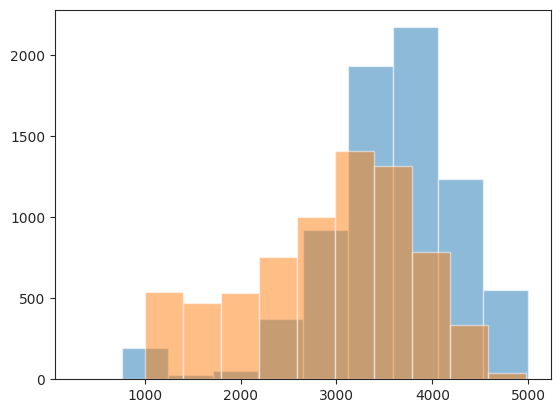

In [190]:
import itertools
temperature_values_gt = [extract_keyhole_temperatures(t[0], 40, plot = False) for t in concat_samples(targets)]
temperature_values_ddim = {}
new_temperature_values_ddim = {}
for skip, result in result_ddim_skips.items():
    # print(result.shape)
    temperature_values_ddim[skip] = [extract_keyhole_temperatures(t[0], 40, plot = False) for t in concat_samples(result)]
    new_temperature_values_ddim[skip] = [extract_keyhole_temperatures(t[0], 40, plot = False) for t in concat_samples(new_result_ddim_skips[skip])]
temperature_values_cnn = [extract_keyhole_temperatures(t[0], 40, plot = False) for t in concat_samples(results_cnn)]
temperature_values_diffusion = [extract_keyhole_temperatures(t[0], 40, plot = False) for t in concat_samples(results_diffusion)]
new_temperature_values_diffusion = [extract_keyhole_temperatures(t[0], 40, plot = False) for t in concat_samples(new_results_diffusion)]
temperature_values_gt = list(itertools.chain(*temperature_values_gt))
temperature_values_cnn = list(itertools.chain(*temperature_values_cnn))
temperature_values_diffusion = list(itertools.chain(*temperature_values_diffusion))
new_temperature_values_diffusion = list(itertools.chain(*new_temperature_values_diffusion))
for skip, values in temperature_values_ddim.items():
    # print(temperature_values_ddim[skip])
    temperature_values_ddim[skip] = list(itertools.chain(*values))
    new_temperature_values_ddim[skip] = list(itertools.chain(*new_temperature_values_ddim[skip]))


# plt.show()
print(temperature_values_gt)
plt.hist(temperature_values_gt, alpha = 0.5)
plt.hist(temperature_values_cnn, alpha = 0.5)
plt.show()

In [191]:
def get_min_keyhole_temperature(temperatures):
    minimums  = []
    for t in tqdm(concat_samples(temperatures)):
        if len(extract_keyhole_temperatures(t[0], 40, plot = False)) > 0:
            minimums.append(np.min(extract_keyhole_temperatures(t[0], 40, plot = False)))

    return minimums

In [193]:
# minimum_temperature_values_gt = [np.min(extract_keyhole_temperatures(t[0], 40, plot = False)) for t in concat_samples(targets)]
min_gt_temperatures = get_min_keyhole_temperature(targets)
min_cnn_temperatures = get_min_keyhole_temperature(results_cnn)
min_diffusion_temperatures = get_min_keyhole_temperature(results_diffusion)
new_min_diffusion_temperatures = get_min_keyhole_temperature(new_results_diffusion)
min_ddim_temperatures = {}
new_min_ddim_temperatures = {}
for skip, values in temperature_values_ddim.items():
    min_ddim_temperatures[skip] = get_min_keyhole_temperature(result_ddim_skips[skip])
    new_min_ddim_temperatures[skip] = get_min_keyhole_temperature(new_result_ddim_skips[skip])


100%|██████████| 300/300 [00:02<00:00, 135.82it/s]


In [162]:
# temperature_values_gt


[3269.7983,
 3340.6543,
 3307.1985,
 2792.1938,
 3816.5203,
 3226.1155,
 3179.7144,
 3157.5897999999997,
 3189.8911,
 3305.8774000000003,
 3377.5789,
 3443.5005,
 3485.2202,
 3454.7944,
 4153.8228,
 4245.1875,
 3533.835,
 3554.825,
 3388.0173,
 3623.2007,
 3540.2361,
 3491.3212999999996,
 4831.5952,
 3563.6682,
 3645.7302,
 3501.1859999999997,
 3523.0576,
 3590.1023,
 3712.626,
 3836.1587,
 3080.834,
 2422.5769,
 3825.7947,
 4573.7217,
 4953.9121,
 4603.9697,
 4846.4038,
 3830.2947,
 3487.1577,
 4481.2495,
 3599.2947000000004,
 3070.8679,
 3151.1892,
 3428.9885,
 3459.6235,
 3433.5334,
 3507.1389,
 3934.3145000000004,
 4063.1931000000004,
 4268.2886,
 4203.659199999999,
 3606.0999,
 3162.0671,
 3255.0215,
 3300.3027,
 3201.3765,
 3183.2978999999996,
 3089.5898,
 3202.6677,
 3615.2021,
 3823.2908,
 2892.0044,
 3266.1401,
 3621.499,
 3901.3398,
 3996.8625,
 4321.1987,
 4520.579599999999,
 4383.0244,
 4248.4375,
 3505.1892,
 2871.2871,
 2306.1592,
 2434.4368,
 2439.5059,
 2483.4346,
 2553

In [163]:
temperature_values_gt[0]

3269.7983

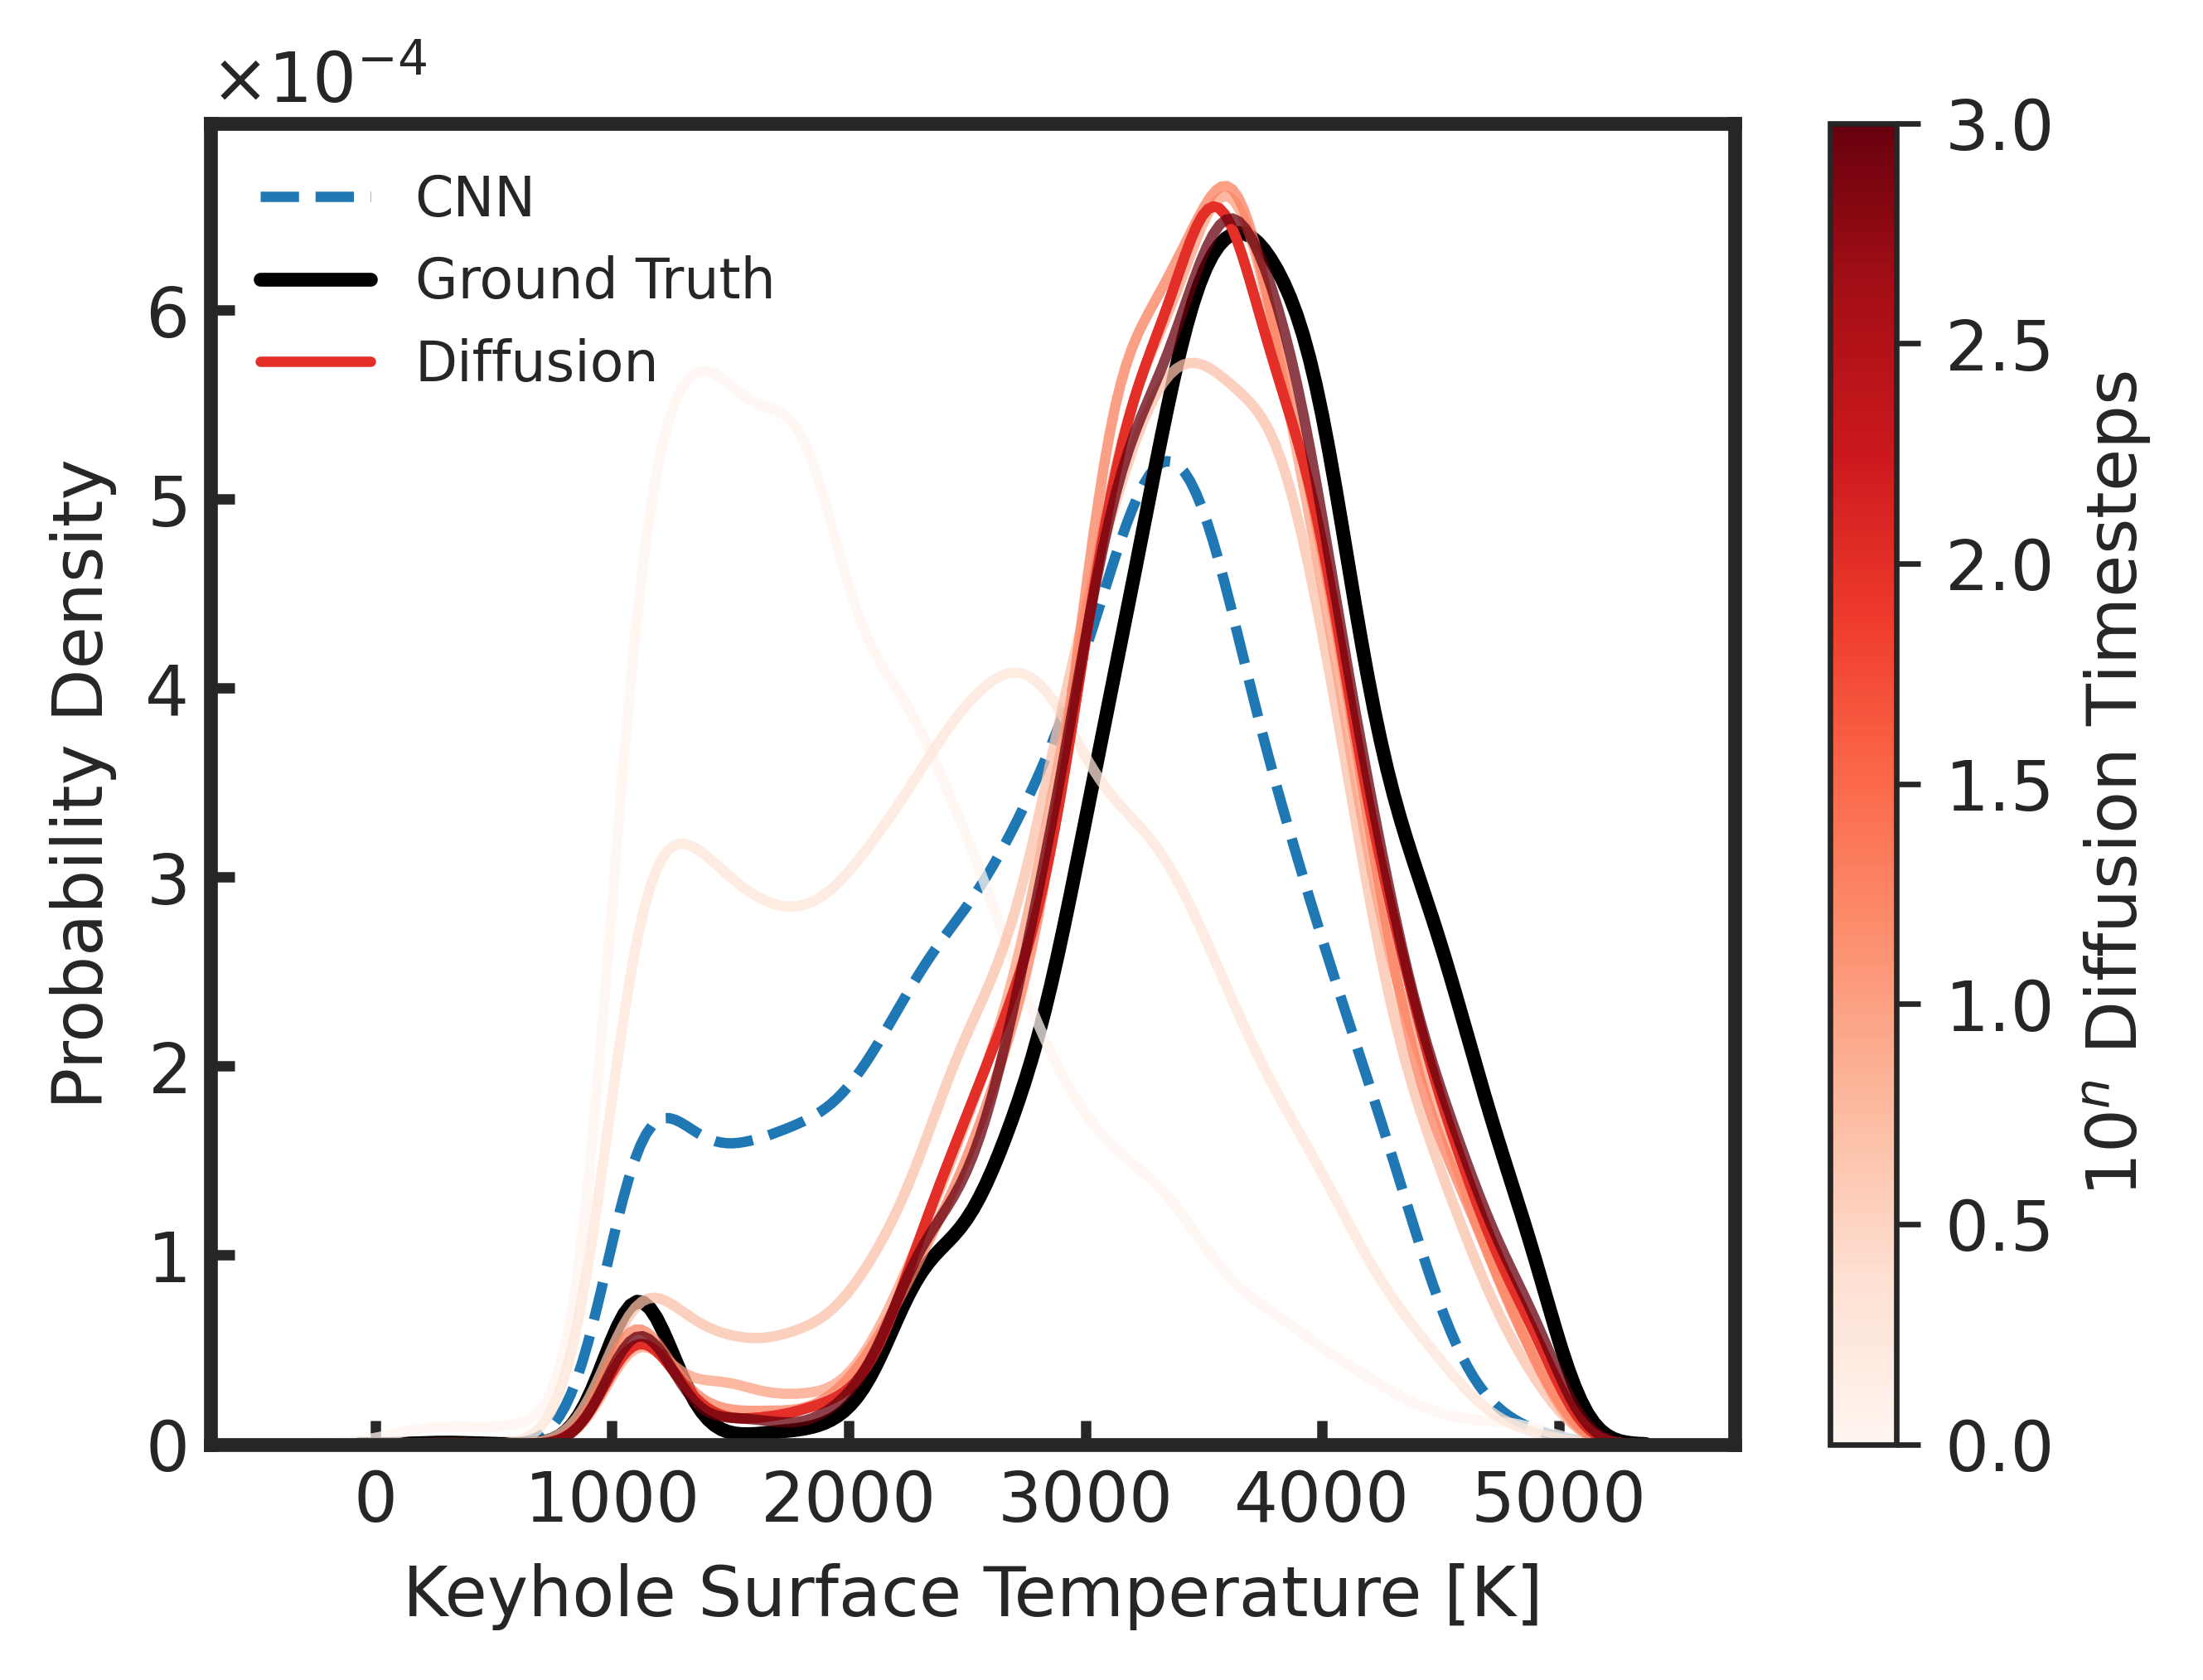

In [194]:
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib import cm
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import ScalarFormatter


plt.figure(dpi= 600, figsize = np.array([4.3,3])*1.15)
frame_tick()
plt.xlabel('Keyhole Surface Temperature [K]')
plt.ylabel('Probability Density')
sns.kdeplot(temperature_values_cnn, label = 'CNN', linestyle = '--')
skip_values=np.log10(1000/np.array(list(temperature_values_ddim.keys())))
norm = Normalize(vmin=0, vmax=max(skip_values))

sns.kdeplot(temperature_values_gt, c = 'k', linewidth = 2.0, label = 'Ground Truth')
cmap = cm.get_cmap('Reds')
c = 0
for skip, values in temperature_values_ddim.items():
    color = cmap(norm(np.log10(1000/skip)))
    c += 1
    if c == len(temperature_values_ddim) - 1:
        sns.kdeplot(values,  color = color, label = 'Diffusion')
    sns.kdeplot(values,  alpha =0.75,color =color)
# sns.kdeplot(temperature_values_diffusion)
# plt.colorbar()
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required for the colorbar to work
plt.legend(frameon = False, fontsize = 8, loc = 'upper left')
# Add the colorbar to the plot
plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='scientific', scilimits=(0, 0))

cbar = plt.colorbar(sm)
cbar.set_label(rf'$10^n$ Diffusion Timesteps')
# plt.show
# plt.legend()

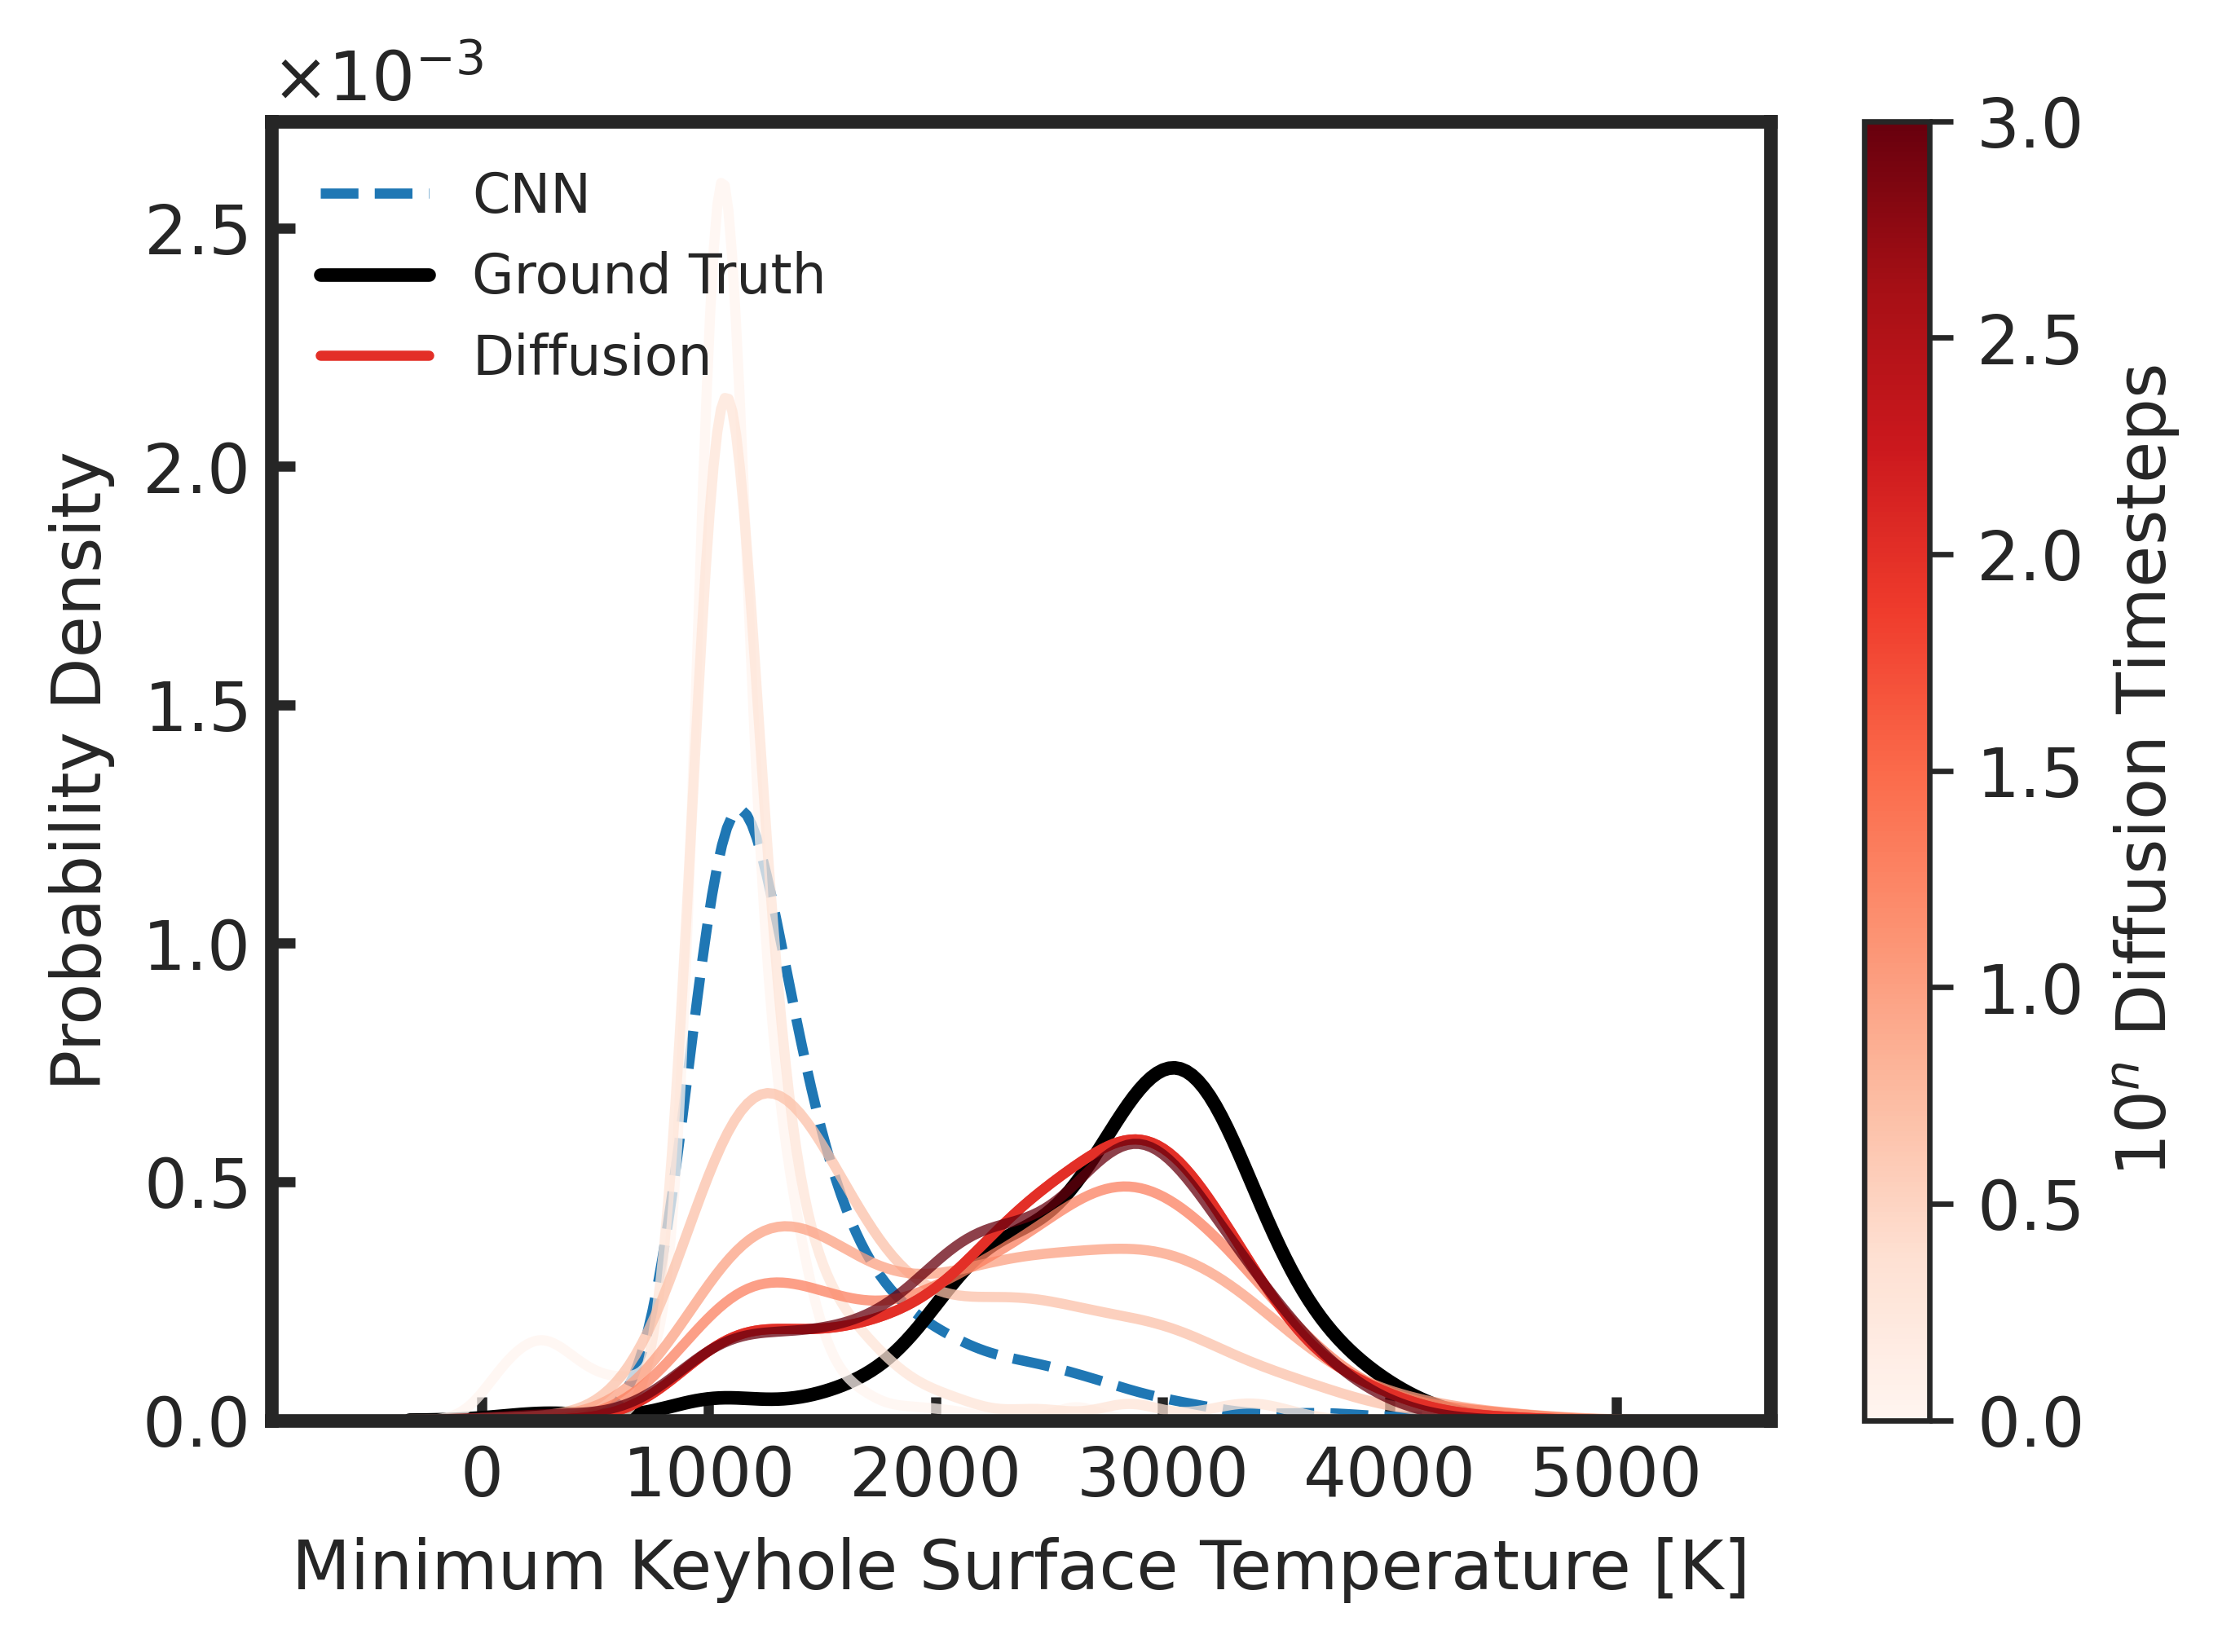

In [195]:
plt.figure(dpi= 600, figsize = np.array([4.3,3])*1.15)
frame_tick()
plt.xlabel('Minimum Keyhole Surface Temperature [K]')
plt.ylabel('Probability Density')
sns.kdeplot(min_cnn_temperatures, label = 'CNN', linestyle = '--')
skip_values=np.log10(1000/np.array(list(min_ddim_temperatures.keys())))
norm = Normalize(vmin=0, vmax=max(skip_values))

sns.kdeplot(min_gt_temperatures, c = 'k', linewidth = 2.0, label = 'Ground Truth')
cmap = cm.get_cmap('Reds')
c = 0
for skip, values in min_ddim_temperatures.items():
    color = cmap(norm(np.log10(1000/skip)))
    c += 1
    if c == len(min_ddim_temperatures) - 1:
        sns.kdeplot(values,  color = color, label = 'Diffusion')
    sns.kdeplot(values,  alpha =0.75,color =color)
# sns.kdeplot(temperature_values_diffusion)
# plt.colorbar()
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required for the colorbar to work
plt.legend(frameon = False, fontsize = 8, loc = 'upper left')
# Add the colorbar to the plot
plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='scientific', scilimits=(0, 0))
# sns.kdeplot(min_diffusion_temperatures, c = 'k', linewidth = 2.0, label = 'Ground Truth')

cbar = plt.colorbar(sm)
cbar.set_label(rf'$10^n$ Diffusion Timesteps')
# plt.show
# plt.legend()

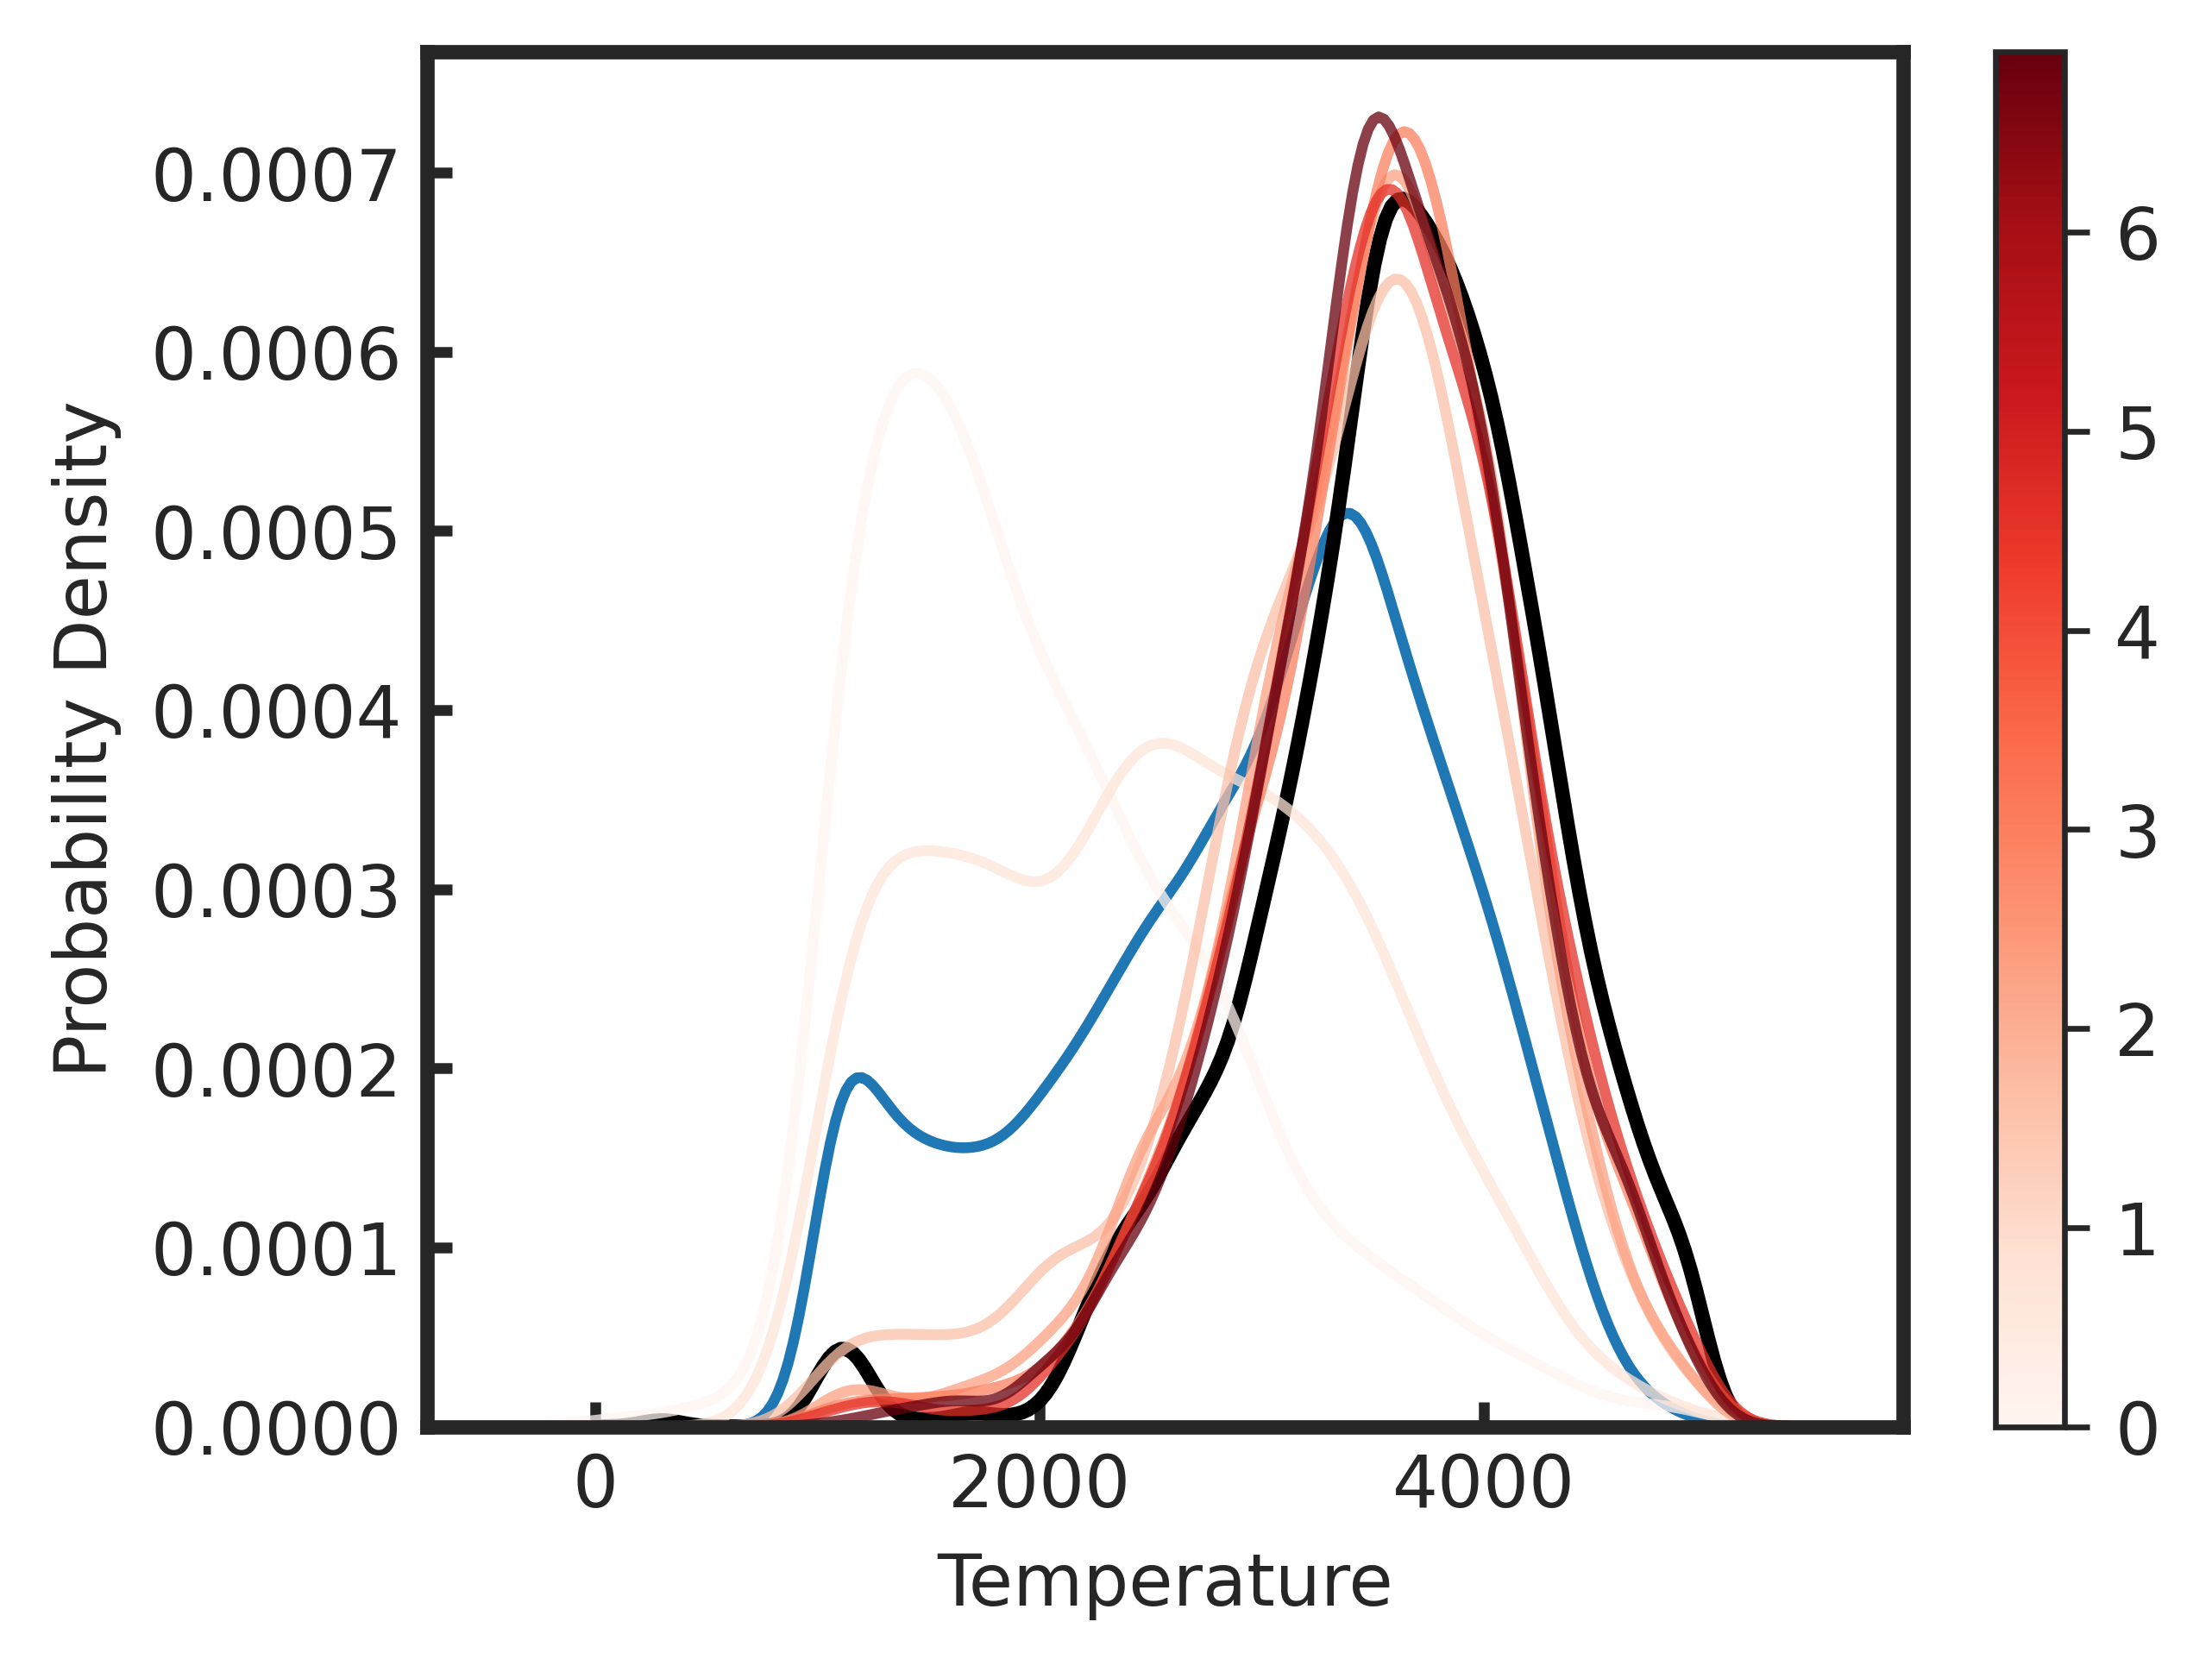

In [165]:
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib import cm
from matplotlib.cm import ScalarMappable

plt.figure(dpi= 600, figsize = np.array([4,3])*1.15)
frame_tick()
plt.xlabel('Temperature')
plt.ylabel('Probability Density')
sns.kdeplot(temperature_values_cnn)
skip_values=np.log(1000/np.array(list(temperature_values_ddim.keys())))
norm = Normalize(vmin=0, vmax=max(skip_values))

sns.kdeplot(temperature_values_gt, c = 'k', linewidth = 2.0)
cmap = cm.get_cmap('Reds')
for skip, values in temperature_values_ddim.items():
    color = cmap(norm(np.log(1000/skip)))
    sns.kdeplot(values,  alpha =0.75,color =color, label = f'Skip: {skip}')
# sns.kdeplot(temperature_values_diffusion)
# plt.colorbar()
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required for the colorbar to work

# Add the colorbar to the plot
cbar = plt.colorbar(sm)
cbar.set_label('')
# plt.show
# plt.legend()

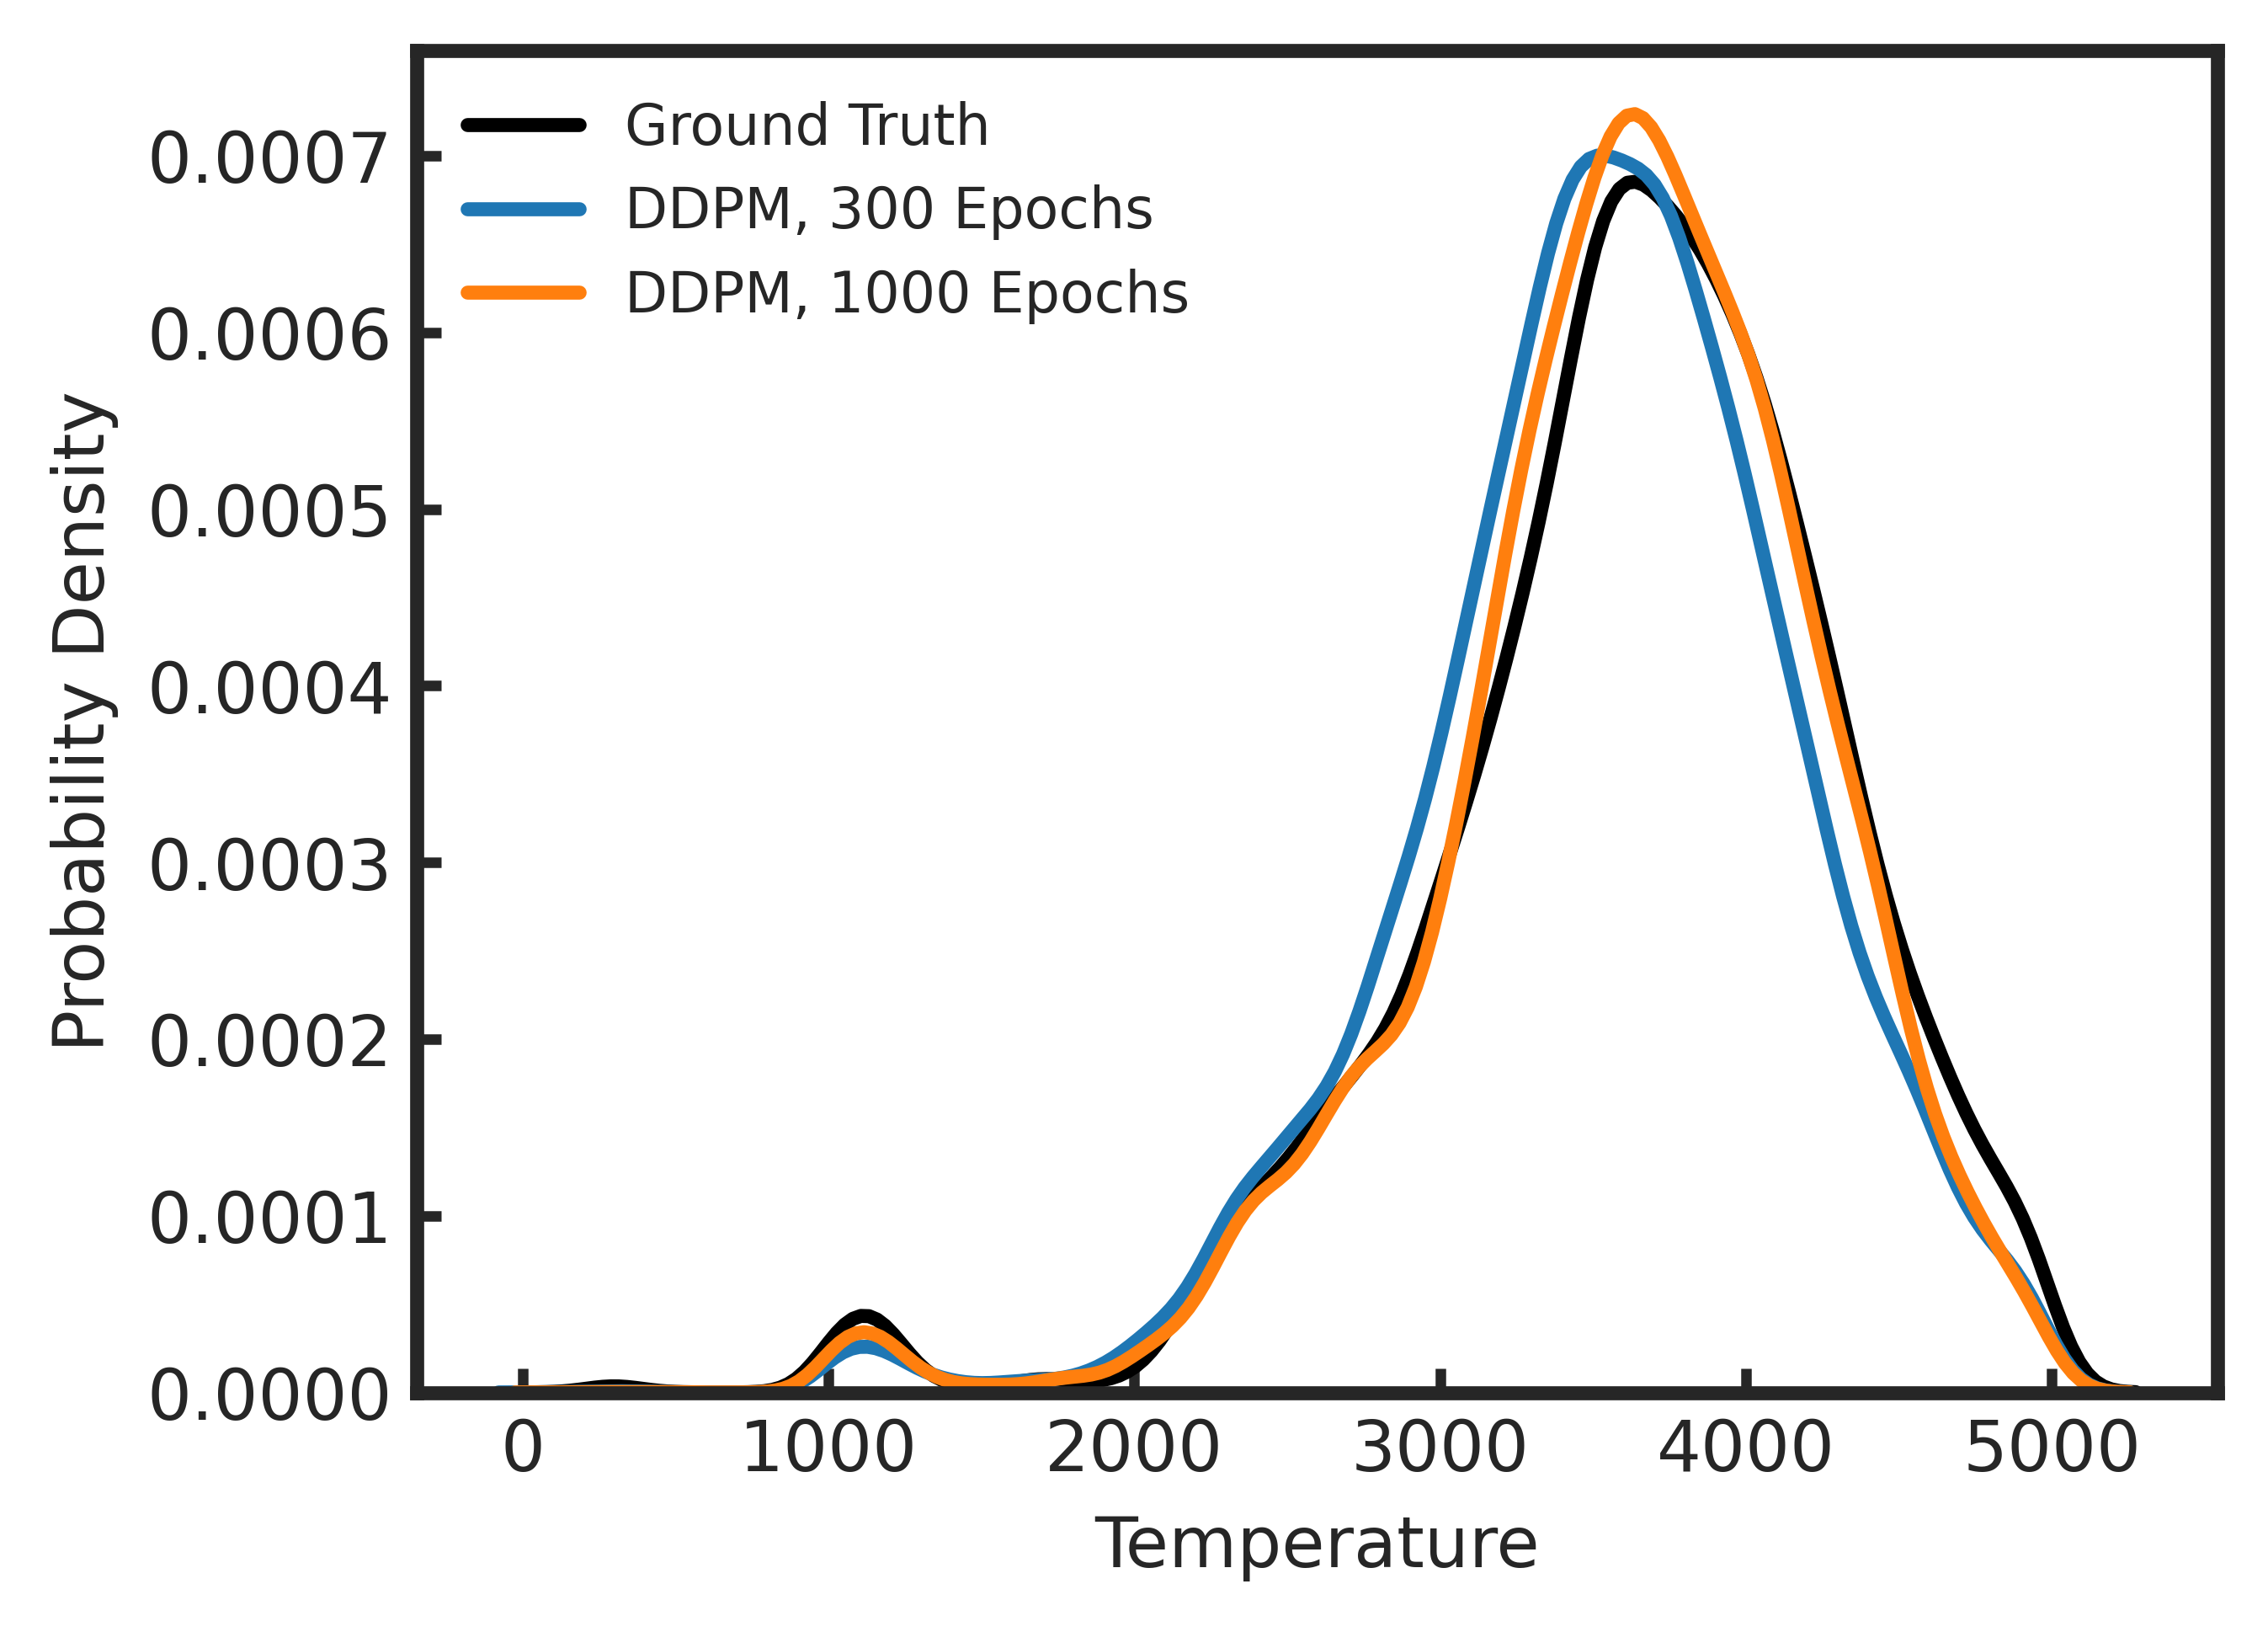

In [166]:
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib import cm
from matplotlib.cm import ScalarMappable

plt.figure(dpi= 600, figsize = np.array([4,3])*1.15)
frame_tick()
plt.xlabel('Temperature')
plt.ylabel('Probability Density')
# sns.kdeplot(temperature_values_cnn)
skip_values=1000/np.array(list(temperature_values_ddim.keys()))
norm = Normalize(vmin=0, vmax=max(skip_values))

sns.kdeplot(temperature_values_gt, c = 'k', linewidth = 2.0,label = 'Ground Truth')
sns.kdeplot(temperature_values_diffusion, linewidth = 2.0, label = 'DDPM, 300 Epochs')
sns.kdeplot(new_temperature_values_diffusion, linewidth = 2.0, label = 'DDPM, 1000 Epochs')

plt.legend(frameon = False, fontsize = 8)
plt.show()


<AxesSubplot:ylabel='Density'>

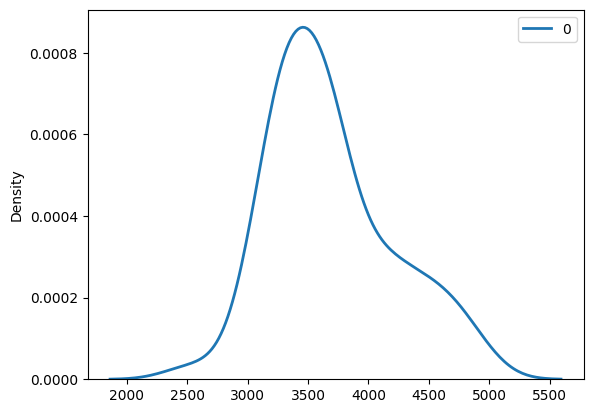

In [73]:
plt.clf()
sns.kdeplot(temperature_values_gt, color = 'black', linewidth = 2.0)


In [27]:

def kl_divergence(p, q):
    # Normalize the distributions
    p = p / np.sum(p)
    q = q / np.sum(q)
    
    # Add a small value to avoid division by zero and log of zero
    epsilon = 1e-10
    p = np.clip(p, epsilon, 1)
    q = np.clip(q, epsilon, 1)
    
    # Calculate KL divergence
    kl_div = np.sum(p * np.log(p / q))
    return kl_div


In [28]:
from scipy.stats import wasserstein_distance
# for key in temperature_values_ddim.keys():
#     print(key, wasserstein_distance(temperature_values_gt, temperature_values_ddim[key]))
# print(wasserstein_distance(temperature_values_gt, temperature_values_cnn))
print(wasserstein_distance(temperature_values_gt, temperature_values_diffusion))
# wasserstein_distance(temperature_values_gt, temperature_values_ddim[100])

NameError: name 'temperature_values_gt' is not defined

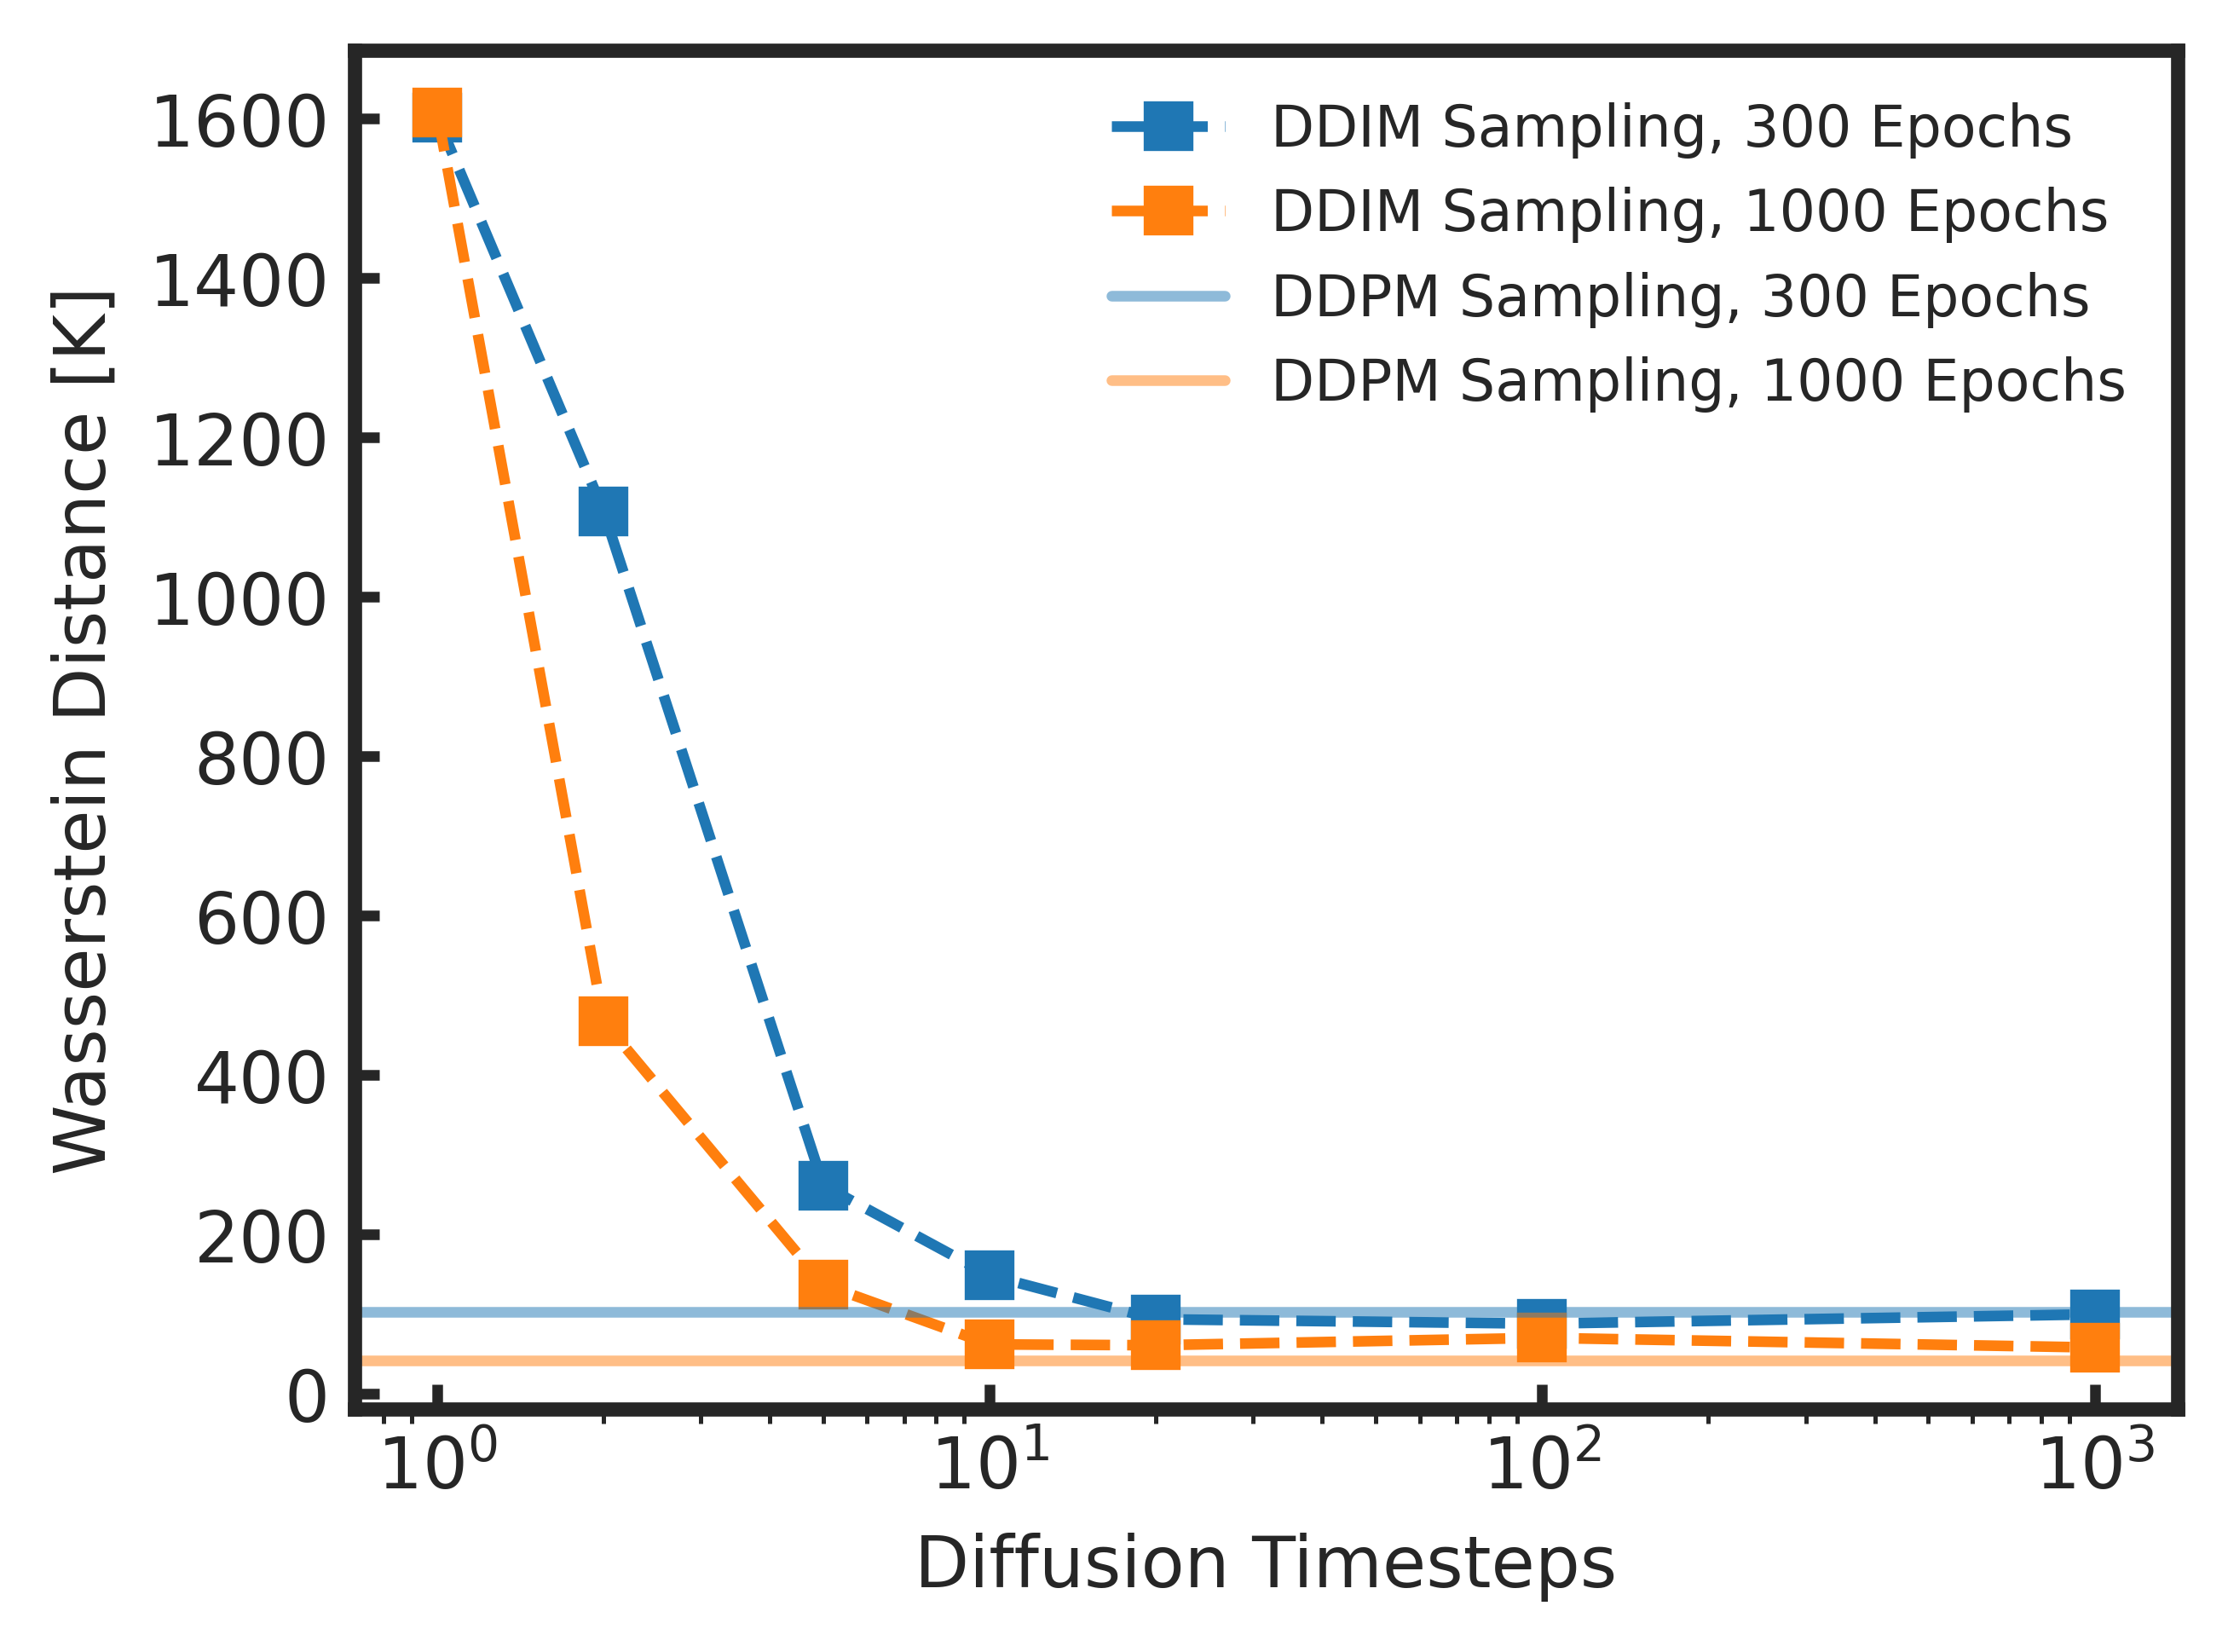

In [170]:
valid_skip_values = list(temperature_values_ddim.keys())
import seaborn 
sns.set_style('ticks')
plt.figure(dpi= 600, figsize = np.array([4,3])*1.15)
plt.ylabel("Wasserstein Distance [K]")
plt.plot(1000/np.array(valid_skip_values), [wasserstein_distance(temperature_values_gt, temperature_values_ddim[key]) for key in valid_skip_values], 's--', label= 'DDIM Sampling, 300 Epochs')
plt.plot(1000/np.array(valid_skip_values), [wasserstein_distance(temperature_values_gt, new_temperature_values_ddim[key]) for key in valid_skip_values], 's--', label= 'DDIM Sampling, 1000 Epochs')


plt.axhline(wasserstein_distance(temperature_values_gt, temperature_values_diffusion), linestyle = '-',  alpha = 0.5, c='#1f77b4', label = 'DDPM Sampling, 300 Epochs')
plt.axhline(wasserstein_distance(temperature_values_gt, new_temperature_values_diffusion), linestyle = '-',  alpha = 0.5, c='#ff7f0e', label = 'DDPM Sampling, 1000 Epochs')
# plt.axhline(wasserstein_distance(temperature_values_gt, temperature_values_cnn), linestyle = '-', label = 'CNN Prediction', c = '#2ca02c', alpha = 0.5)

plt.legend(frameon = False, fontsize = 8) 
frame_tick()
# plt.ylim(0, 500)
plt.xlabel("Diffusion Timesteps")
plt.xscale('log')
# plt.ylim([0,200])

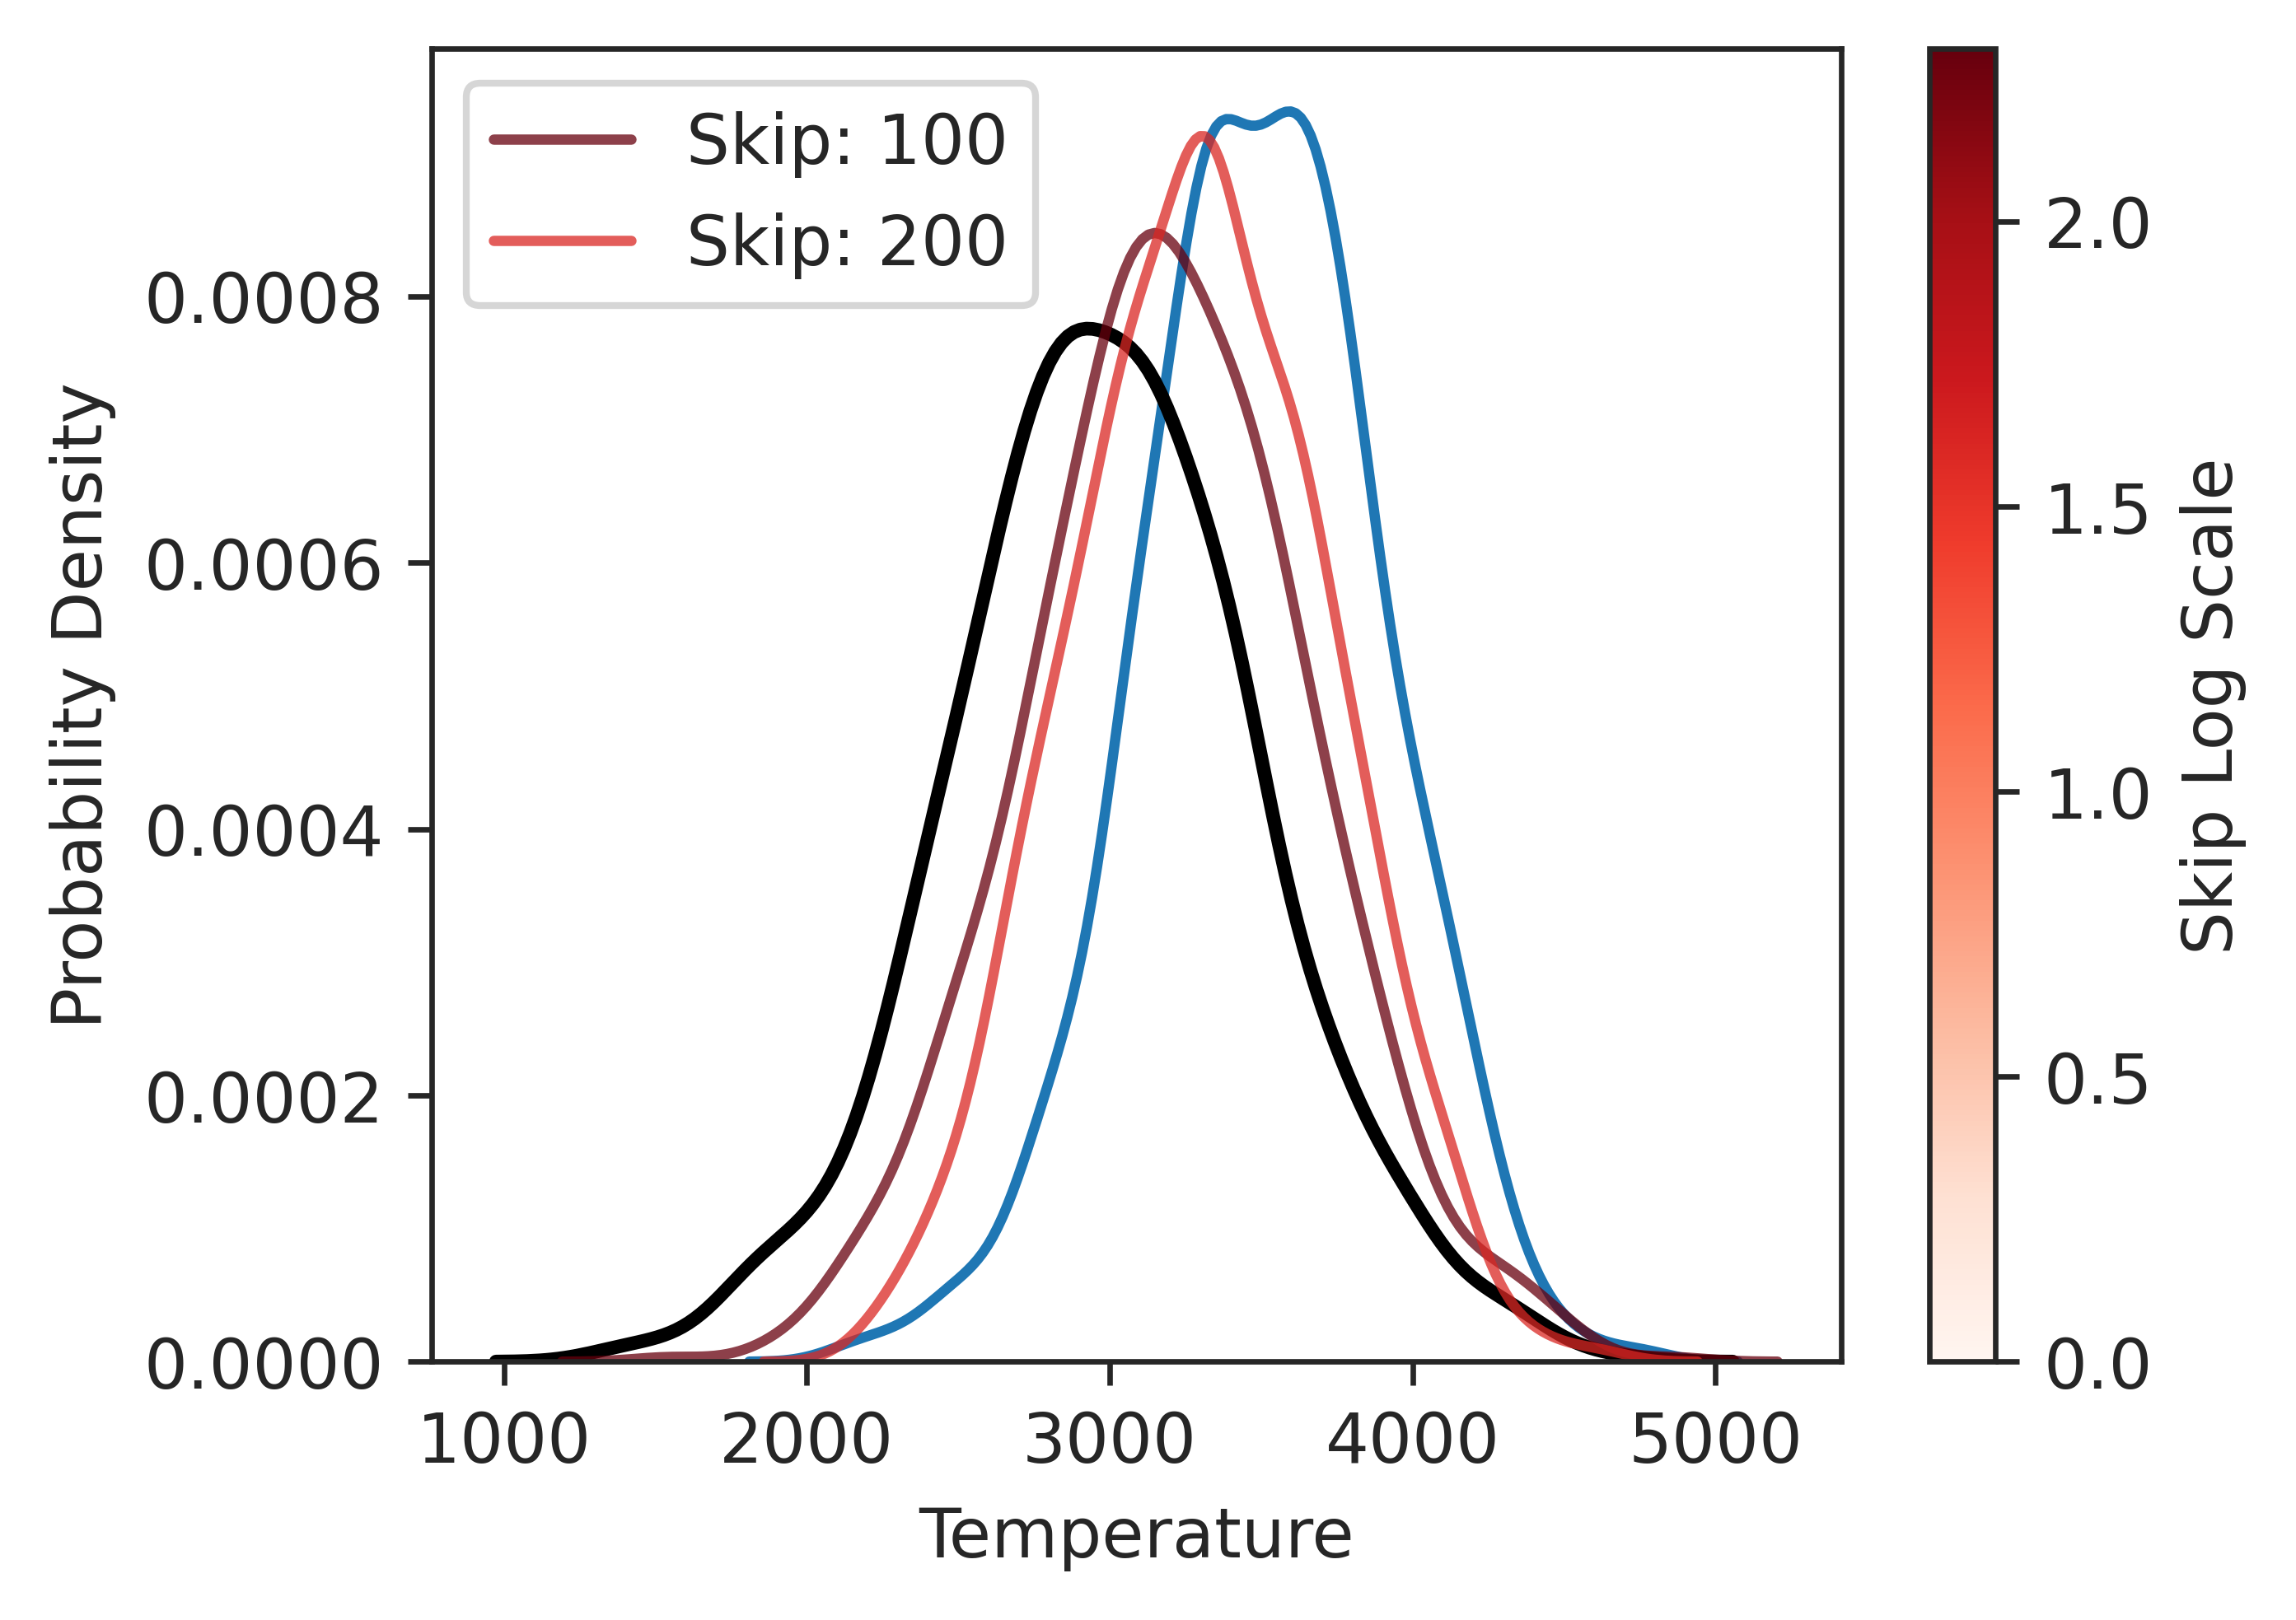

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from matplotlib import cm
from matplotlib.cm import ScalarMappable

# Example data
temperature_values_gt = np.random.normal(loc=3000, scale=500, size=1000)
temperature_values_cnn = np.random.normal(loc=3500, scale=400, size=1000)
temperature_values_ddim = {100: np.random.normal(loc=3200, scale=450, size=1000), 
                           200: np.random.normal(loc=3300, scale=420, size=1000)}

plt.figure(dpi=600, figsize=np.array([4, 3]) * 1.15)
plt.xlabel('Temperature')
plt.ylabel('Probability Density')
sns.kdeplot(temperature_values_cnn)
skip_values = np.log(1000 / np.array(list(temperature_values_ddim.keys())))
norm = Normalize(vmin=0, vmax=max(skip_values))

# Plot ground truth
sns.kdeplot(temperature_values_gt, color='k', linewidth=2.0)

# Colormap and normalization
cmap = cm.get_cmap('Reds')
for skip, values in temperature_values_ddim.items():
    color = cmap(norm(np.log(1000 / skip)))
    sns.kdeplot(values, alpha=0.75, color=color, label=f'Skip: {skip}')

# Create the scalar mappable for the colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required for the colorbar to work

# Add the colorbar to the plot
cbar = plt.colorbar(sm)
cbar.set_label('Skip Log Scale')

# Show the legend
plt.legend()

# Show the plot
plt.show()

In [90]:
# wasserstein_distance(temperature_values_gt, new_temperature_values_diffusion)
new_temperature_values_diffusion

[array([3239.3593592 , 3129.68843932, 3111.97385981, 3159.32189131,
        3245.38000349, 3046.54355234, 3103.45300161, 3007.80877386,
        3129.12027526, 3419.4923684 , 3251.01841329, 3253.34037164,
        3697.60752659, 3743.41145904, 3703.71753119, 3477.08137683,
        3130.0759227 , 3420.08131489, 3653.67853355, 3225.85632922,
        3416.57413278, 3198.67907638, 3269.59541002, 3063.19990033,
        3098.49721661, 3229.65123715, 3395.86153701, 3483.50465688,
        3363.3402751 , 3425.76633703, 3515.73037349, 3781.53427256,
        4171.90252396, 4564.20459512, 4374.92089255, 3558.65821906,
        3701.25703041, 3753.91945979, 4068.13764579, 4146.82759896,
        4547.21852908, 4280.18366473, 4007.84771121, 4027.78953007,
        3625.2718593 , 3735.96021584, 3526.0518496 , 2842.55589005,
        3049.23078427, 3086.31861126, 3340.14261838, 3604.8763608 ,
        3762.18420195, 3842.3548695 , 3610.90893847, 3763.6035806 ,
        3738.69222693, 3665.15080164, 3438.21807

In [ ]:
import scipy.stats as stats

kl_divergence = stats.entropy(prob_dist1, prob_dist2)


<AxesSubplot:ylabel='Count'>

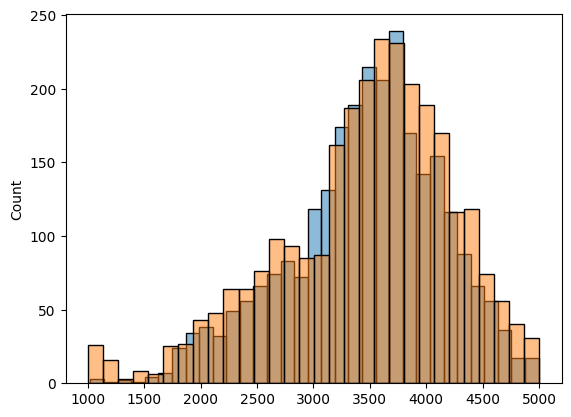

In [31]:
sns.histplot(temperature_values_diffusion, alpha= 0.5)

sns.histplot(temperature_values_gt, alpha = 0.5)

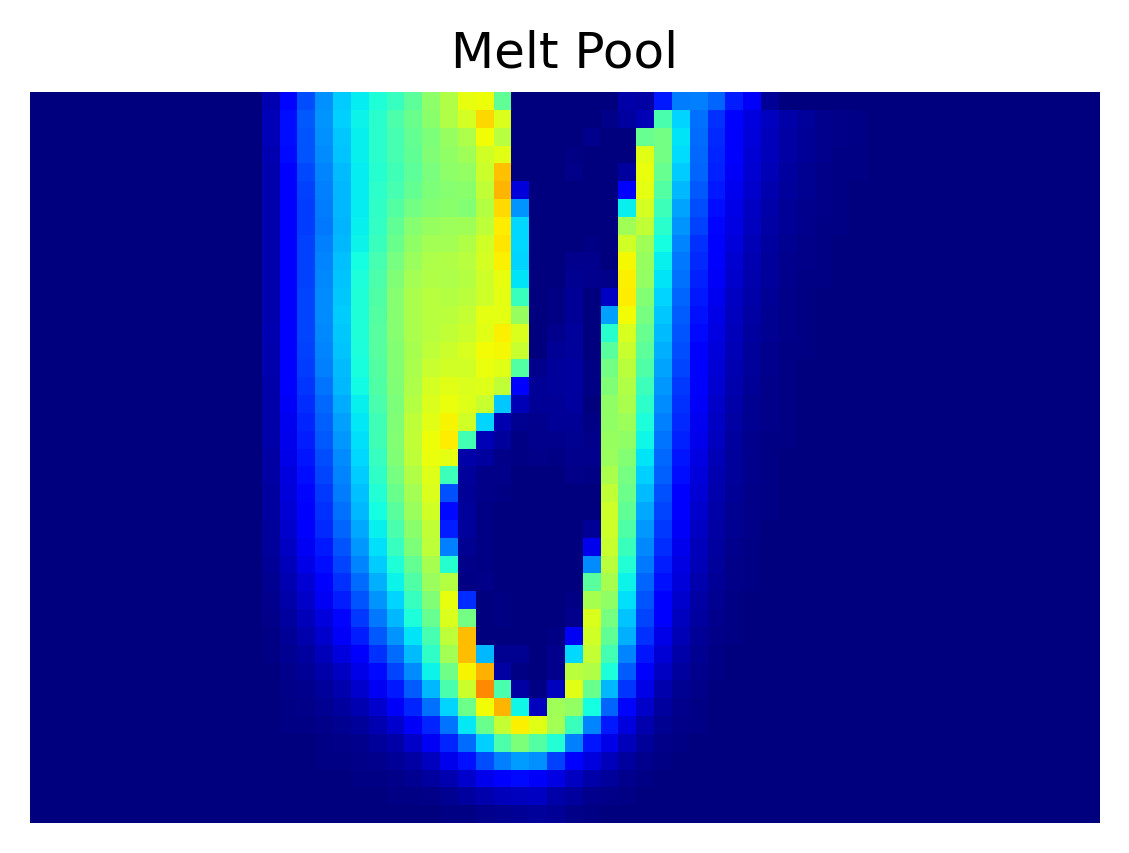

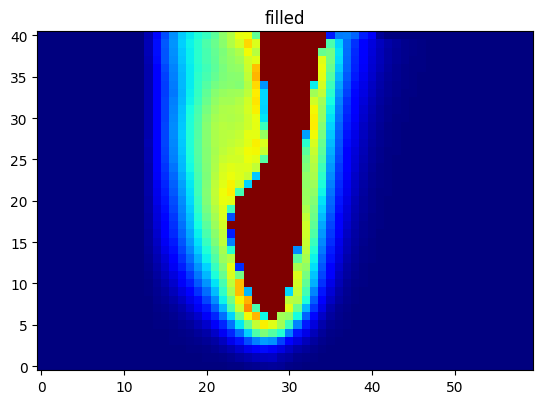

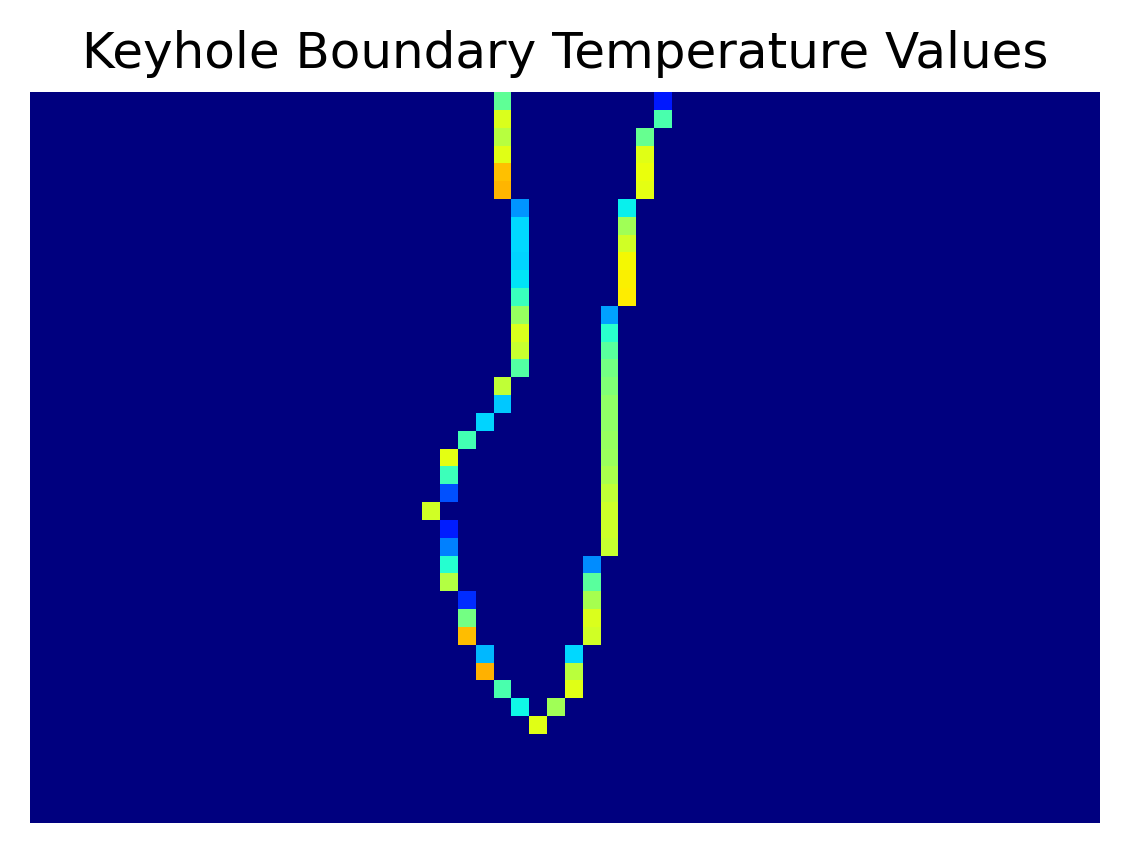

[array([3126.17555472, 2962.30969966, 2161.67209319, 1470.5118815 ,
        1025.17266947, 1262.68171071, 2294.47946806, 3252.1780899 ,
        3627.00805544, 2601.69051596, 1098.83848084, 2332.77910701,
        3689.82216658, 1740.54764527, 1860.72084686, 2352.82822584,
        1805.43512732, 3049.84536244, 3668.50751673, 3608.28848044,
        3221.25768985, 2986.18647288, 3196.21325101, 2495.42830679,
        2037.20152823, 2421.35124133, 3085.40906841, 3184.31356872,
        2805.90130396, 2276.54541597, 1938.61409259, 1857.44776134,
        1878.43755853, 1881.49384039, 1579.57404586, 3217.9313918 ,
        2855.17366071, 3234.01741441, 2999.95458016, 1880.14170774,
        3140.76234261, 3182.90833142, 2898.30609986, 2450.36150307,
        1541.39333982, 3074.25959212, 3109.80200229, 3122.53529631,
        3045.43105918, 2906.23806008, 2819.17906416, 2798.91830307,
        2767.87701543, 2762.26900826, 2665.61507986, 2600.10746268,
        2446.78988221, 2185.79500756, 1627.43569

In [108]:
# plt.hist(temperature_values_cnn)
# results_cnn
[extract_keyhole_temperatures(t[0][0], 41, plot = True) for t in results_cnn[:2]]
# plt.imshow(results_cnn[0][0][0].T, origin = 'lower', cmap = 'jet', vmin = 293, vmax = 5000)
# extract_keyhole_temperatures(results_cnn[0][0][0], 41, plot = True)


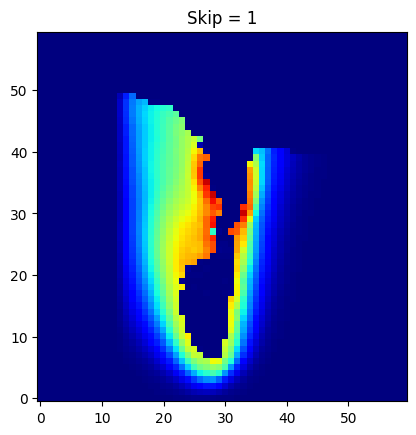

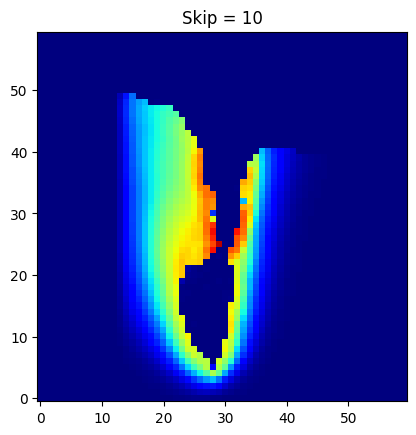

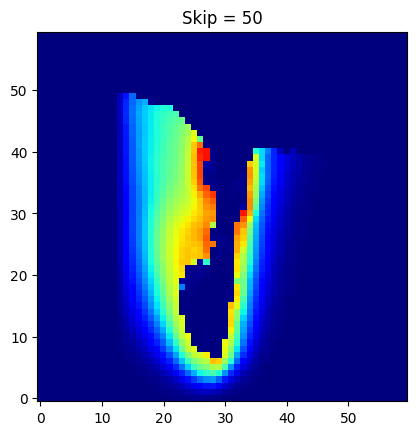

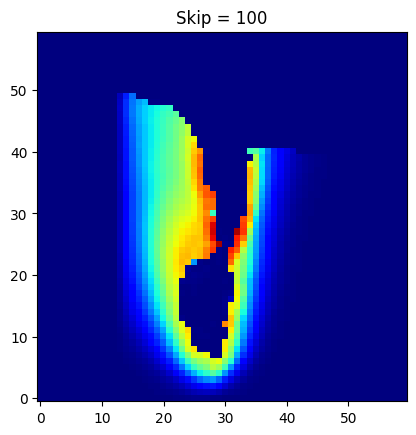

In [54]:
for skip_idx in result_ddim_skips.keys():
    plt.imshow(result_ddim_skips[skip_idx][0][0].T, cmap = 'jet', origin = 'lower', vmin = 293, vmax = 5000)
    plt.title(f'Skip = {skip_idx}')
    plt.show()

In [ ]:
# plt.imshow(sample_output[-1][0][0].detach().numpy())
results_ddim_total = concat_samples(results_ddim)
inputs_total = concat_samples(inputs)
results_cnn_total = concat_samples(results_cnn)
targets_total = concat_samples(targets)
# torch.stack(results_ddim).reshape(len(results_ddim)*len(results_ddim[0]), results_ddim[0].shape[1], results_ddim[0].shape[2], results_ddim[0].shape[3]).shape

In [ ]:
batch_size = 2
from diffusionsr.runners.train_diffusion import num_to_groups
batches = num_to_groups(1, batch_size)
print(lr.shape)
input_lr = lr.to(device).float()
x_e = forwardpass(diff_model.lr_enc, input_lr, factor = diff_model.train_dataset.factor, output = diff_model.enc_output,transform_rescale=diff_model.transform_rescale, dataset = diff_model.train_dataset)
all_images_list = list(map(lambda n: diff_model.sample(diff_model.model, timesteps=timesteps, x_e=x_e,
                    image_size=diff_model.train_dataset.img_shape,  batch_size=batch_size, channels=diff_model.channels), batches))[0]

torch.Size([1, 1, 30, 30])


sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
batch_size = 2
batches = num_to_groups(10,10)
initial_output = list(map(lambda n: diff_model.sample(diff_model.model, timesteps=timesteps, x_e=x_e,
                    image_size=diff_model.train_dataset.img_shape,  batch_size=batch_size, channels=diff_model.channels), batches))

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
# num_to_groups(10,10)
# batch_size
# len(initial_output[1])
import time
times = []
for batch_size in [1, 5, 20, 40, 80, 200]:
    oldtime = time.time()
    sample_output = diff_model.sample(diff_model.model, timesteps=timesteps, x_e=x_e.repeat(batch_size,1,1 ,1 ),
                        image_size=diff_model.train_dataset.img_shape,  batch_size=batch_size, channels=diff_model.channels)
    elapsed_time = time.time() - oldtime
    times.append(elapsed_time)

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

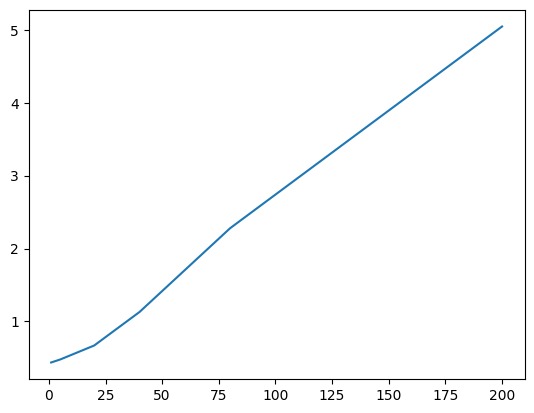

In [ ]:
batch_sizes = [1, 5, 20, 40, 80, 200]
plt.plot(batch_sizes, np.array(times)/60)

(0.0, 30.0)

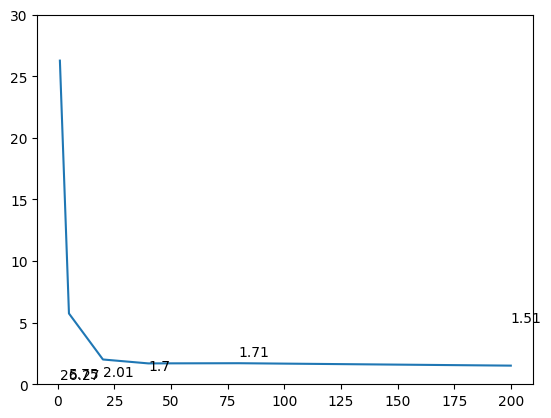

In [ ]:
plt.plot(batch_sizes, np.array(times)/np.array(batch_sizes))
for i, txt in enumerate(np.array(times)/np.array(batch_sizes)):
    plt.annotate(f'{round(txt, 2)}', (batch_sizes[i], times[i]/60))
# plt.ylim([0, 0.5])
plt.ylim([0, 30])

In [ ]:
np.array(times)/np.array(batch_sizes)

array([25.79226422,  5.28944325,  2.02192649,  1.69953096,  1.71329996])

In [ ]:
sample_output[0].shape

torch.Size([80, 1, 60, 60])